### Ultimate MLOps, Cloud & Linux Notebook

**Comprehensive interview preparation & reference guide** covering MLOps, model deployment, cloud platforms (AWS & Azure), Linux administration, and Git — **650+ questions** with detailed notes, code examples, and system design patterns.

---

## Table of Contents

| #   | Section | Topics | Questions |
| --- | ------- | ------ | --------- |
| 1   | [**MLOps Fundamentals**](#mlops-fundamentals) | ML lifecycle, maturity, versioning, MLOps vs DevOps | 30 |
| 2   | [**Docker — Containerization**](#docker) | Dockerfile, Compose, multi-stage builds, GPU support | 25 |
| 3   | [**Kubernetes — Orchestration**](#kubernetes) | Pods, deployments, services, HPA, GPU scheduling | 25 |
| 4   | [**CI/CD for ML**](#cicd) | Pipeline stages, model validation, GitOps, GitHub Actions | 25 |
| 5   | [**Model Serving & Deployment**](#model-serving) | FastAPI, Triton, vLLM, TorchServe, BentoML, ONNX | 30 |
| 6   | [**Model Monitoring & Drift**](#monitoring) | Data/concept/prediction drift, PSI, KS test, Evidently | 25 |
| 7   | [**ML System Design Patterns**](#system-design) | Recommendation, fraud, search, RAG, design framework | 25 |
| 8   | [**Experiment Tracking**](#experiment-tracking) | MLflow, W&B, model registry, reproducibility | 25 |
| 9   | [**Feature Stores**](#feature-stores) | Feast, Tecton, online vs offline, point-in-time | 15 |
| 10   | [**Model Optimization**](#model-optimization) | Quantization, pruning, distillation, GGUF, TensorRT | 20 |
| 11   | [**ML Pipeline Orchestration**](#ml-pipelines) | Kubeflow, Airflow for ML, Prefect, Dagster, ZenML | 20 |
| 12   | [**AI Ethics & Governance**](#ethics) | Bias, fairness, XAI, adversarial, model cards, regulations | 20 |
| 13   | [**Emerging Trends**](#emerging) | MoE, SSM/Mamba, speculative decoding, DPO, data-centric | 25 |
| 14   | [**Cloud Computing Fundamentals**](#cloud-fundamentals) | IaaS/PaaS/SaaS, regions, AZs, auto-scaling | 25 |
| 15   | [**Cloud Architecture Patterns**](#cloud-architecture) | Lambda/Kappa, microservices, CQRS, data mesh | 20 |
| 16   | [**AWS Cloud Services**](#aws) | EC2, S3, IAM, Lambda, SageMaker, ECR, EKS | 40 |
| 17   | [**Azure Cloud Services**](#azure) | VMs, ADLS, Azure ML, AKS, ACR, Functions | 40 |
| 18   | [**Linux Fundamentals**](#linux-fundamentals) | Kernel, filesystem, processes, permissions, systemd | 40 |
| 19   | [**Linux Shell & Scripting**](#linux-shell) | Bash, grep/sed/awk, pipes, loops, functions, regex | 35 |
| 20   | [**Linux Networking**](#linux-networking) | SSH, firewall, DNS, TCP/UDP, troubleshooting | 25 |
| 21   | [**Git & Version Control**](#git) | Workflow, branching, merge vs rebase, hooks | 25 |
| 22   | [**IaC — Terraform**](#iac) | HCL, state management, modules, plan/apply | 15 |
|     | **TOTAL** | | **~650+** |

---


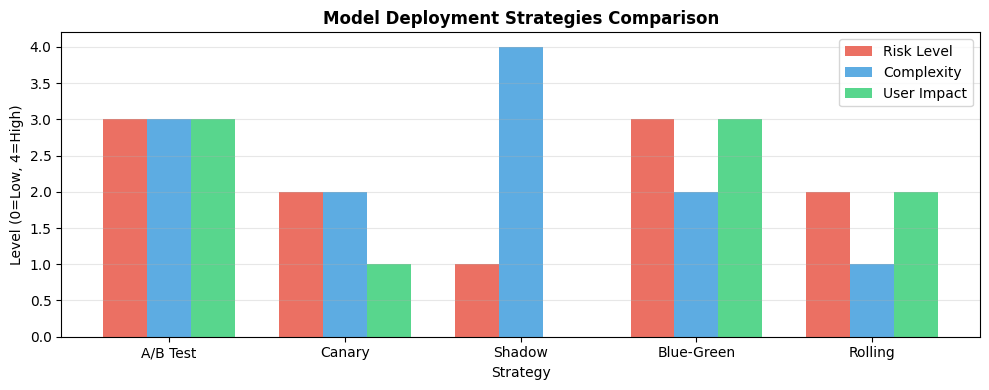

In [5]:
# ──────────────────────────────────────────────
# Deployment Strategies Comparison
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

strategies = ['A/B Test', 'Canary', 'Shadow', 'Blue-Green', 'Rolling']
risk = [3, 2, 1, 3, 2]
complexity = [3, 2, 4, 2, 1]
user_impact = [3, 1, 0, 3, 2]

x = np.arange(len(strategies))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, risk, width, label='Risk Level', color='#e74c3c', alpha=0.8)
ax.bar(x, complexity, width, label='Complexity', color='#3498db', alpha=0.8)
ax.bar(x + width, user_impact, width, label='User Impact', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Strategy')
ax.set_ylabel('Level (0=Low, 4=High)')
ax.set_title('Model Deployment Strategies Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

#### Environment Setup (Google Colab / Local)

In [6]:
# ──────────────────────────────────────────────
# Install required packages (run once)
# ──────────────────────────────────────────────
# !pip install -q flask fastapi uvicorn mlflow wandb
# !pip install -q evidently alibi-detect
# !pip install -q scikit-learn pandas numpy joblib
# !pip install -q docker  # for Docker SDK

In [7]:
# ──────────────────────────────────────────────
# Core Imports
# ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import json, os, time
print("Core imports loaded")

Core imports loaded


---

<a id="mlops-fundamentals"></a>

### Part 1: MLOps Fundamentals

#### ML Lifecycle Stages

| Stage | Activities | Tools |
| --- | --- | --- |
| **Data** | Collect, clean, version, label | DVC, Airflow, LabelStudio |
| **Experiment** | Train, evaluate, compare, tune | MLflow, W&B, Optuna |
| **Deploy** | Package, serve, scale | Docker, K8s, TF Serving, Triton |
| **Monitor** | Track drift, performance, alerts | Evidently, Prometheus, Grafana |
| **Retrain** | Trigger retraining on drift | Airflow, Kubeflow, Vertex AI |

#### MLOps Maturity Levels

| Level | Description | Characteristics |
| --- | --- | --- |
| **0 — Manual** | No MLOps | Jupyter notebooks, manual deploy, no versioning |
| **1 — DevOps** | Basic automation | CI/CD, Docker, basic monitoring |
| **2 — ML Pipeline** | Automated training | Orchestrated pipelines, feature stores |
| **3 — Full MLOps** | Automated everything | Auto retraining, A/B testing, drift detection |

#### Data/Model Versioning

| Tool | Type | Key Feature |
| --- | --- | --- |
| **DVC** | Data versioning | Git-like commands for data and models |
| **MLflow** | Experiment tracking | Parameters, metrics, artifacts, model registry |
| **W&B** | Experiment tracking | Cloud UI, sweeps, artifact management |
| **Git LFS** | Large file storage | Store large files in Git repos |

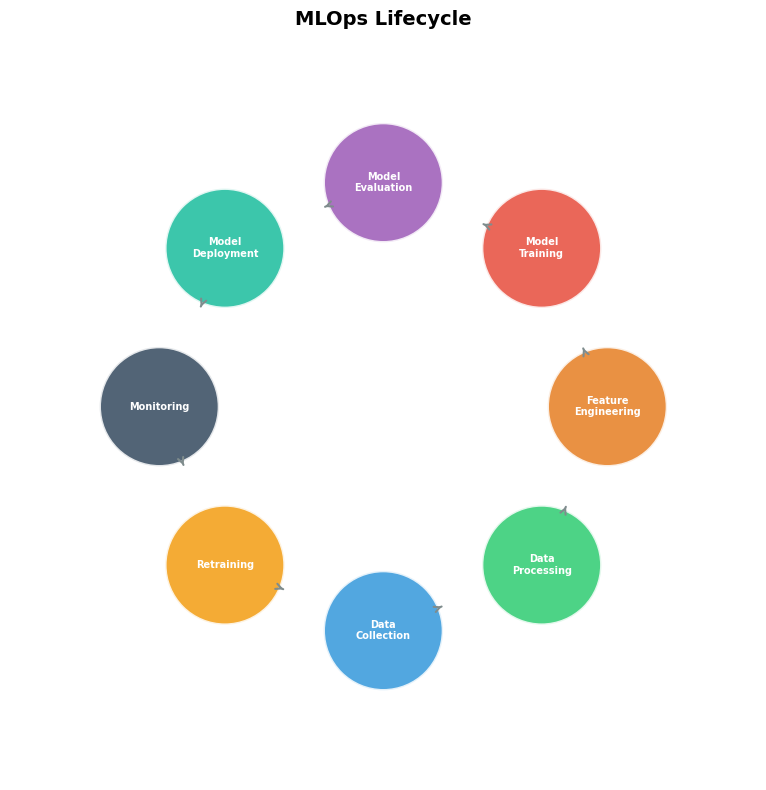

In [8]:
# ──────────────────────────────────────────────
# MLOps Lifecycle Visualization
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

stages = ['Data\nCollection', 'Data\nProcessing', 'Feature\nEngineering',
          'Model\nTraining', 'Model\nEvaluation', 'Model\nDeployment',
          'Monitoring', 'Retraining']
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c',
          '#9b59b6', '#1abc9c', '#34495e', '#f39c12']

n = len(stages)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
radius = 3

for i, (stage, color, angle) in enumerate(zip(stages, colors, angles)):
    x = radius * np.cos(angle - np.pi/2)
    y = radius * np.sin(angle - np.pi/2)
    circle = plt.Circle((x, y), 0.8, facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(circle)
    ax.text(x, y, stage, ha='center', va='center', fontsize=7, fontweight='bold', color='white')
    
    # Arrow to next stage
    next_i = (i + 1) % n
    x2 = radius * np.cos(angles[next_i] - np.pi/2)
    y2 = radius * np.sin(angles[next_i] - np.pi/2)
    dx, dy = x2 - x, y2 - y
    dist = np.sqrt(dx**2 + dy**2)
    ax.annotate('', xy=(x + 0.85*dx/dist, y + 0.85*dy/dist),
                xytext=(x + 0.85*(dx/dist)*0.95, y + 0.85*(dy/dist)*0.95),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('MLOps Lifecycle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

<a id="docker"></a>

### Part 2: Docker — Containerization for ML

#### Docker Key Concepts

| Concept | Description |
| --- | --- |
| **Image** | Read-only template with application + dependencies |
| **Container** | Running instance of an image (isolated process) |
| **Dockerfile** | Instructions to build an image |
| **Registry** | Store for images (Docker Hub, ECR, GCR) |
| **Volume** | Persistent storage mounted into container |
| **Network** | Container communication (bridge, host, overlay) |
| **Docker Compose** | Multi-container applications defined in YAML |

#### Dockerfile Best Practices for ML

| Practice | Description |
| --- | --- |
| **Multi-stage builds** | Separate build from runtime (smaller final image) |
| **Layer caching** | Put rarely-changing instructions first (requirements before code) |
| **Slim base images** | Use python:3.10-slim instead of python:3.10 |
| **Non-root user** | Run as non-root for security |
| **.dockerignore** | Exclude .git, data, __pycache__, .env |

In [9]:
# ──────────────────────────────────────────────
# Dockerfile for ML Model Serving
# ──────────────────────────────────────────────
dockerfile_content = '''
# Multi-stage build for ML model serving
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Runtime stage
FROM python:3.10-slim

WORKDIR /app
COPY --from=builder /usr/local/lib/python3.10/site-packages /usr/local/lib/python3.10/site-packages
COPY --from=builder /usr/local/bin /usr/local/bin

# Copy model and application code
COPY model/ ./model/
COPY app.py .

# Create non-root user
RUN useradd -m appuser
USER appuser

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

print("Dockerfile for ML Model Serving:")
print(dockerfile_content)

# Docker Compose for ML system
compose_content = '''
version: "3.8"
services:
  model-api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    environment:
      - MODEL_PATH=/app/models/model.pkl
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      retries: 3
  
  prometheus:
    image: prom/prometheus
    ports:
      - "9090:9090"
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml
  
  grafana:
    image: grafana/grafana
    ports:
      - "3000:3000"
'''

print("Docker Compose for ML System:")
print(compose_content)

Dockerfile for ML Model Serving:

# Multi-stage build for ML model serving
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Runtime stage
FROM python:3.10-slim

WORKDIR /app
COPY --from=builder /usr/local/lib/python3.10/site-packages /usr/local/lib/python3.10/site-packages
COPY --from=builder /usr/local/bin /usr/local/bin

# Copy model and application code
COPY model/ ./model/
COPY app.py .

# Create non-root user
RUN useradd -m appuser
USER appuser

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Docker Compose for ML System:

version: "3.8"
services:
  model-api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    environment:
      - MODEL_PATH=/app/models/model.pkl
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      retries: 3

  prometheus:
    image: prom/prometheus
    ports:
    

---

<a id="kubernetes"></a>

### Part 3: Kubernetes — Container Orchestration

| Concept | Description |
| --- | --- |
| **Pod** | Smallest deployable unit; one or more containers |
| **Deployment** | Manages pod replicas; rolling updates |
| **Service** | Stable network endpoint for pods (ClusterIP, LoadBalancer) |
| **Ingress** | HTTP routing; SSL termination |
| **HPA** | Horizontal Pod Autoscaler (scale based on CPU/custom metrics) |
| **ConfigMap/Secret** | Configuration and sensitive data management |
| **Persistent Volume** | Durable storage for models and data |

#### ML-Specific Kubernetes Tools

| Tool | Purpose |
| --- | --- |
| **Kubeflow** | End-to-end ML platform on K8s (pipelines, training, serving) |
| **Seldon Core** | ML model deployment and management |
| **KServe** | Serverless model inference on K8s |
| **Argo Workflows** | Workflow orchestration for ML pipelines |

---

<a id="cicd"></a>

### Part 4: CI/CD for Machine Learning

#### CI/CD Pipeline Stages for ML

| Stage | Actions | Tools |
| --- | --- | --- |
| **Code Quality** | Lint, type check, format | flake8, mypy, black |
| **Unit Tests** | Test preprocessing, feature engineering | pytest |
| **Integration Tests** | Test model loading, API endpoints | pytest + Docker |
| **Model Validation** | Check accuracy thresholds, performance regression | Custom scripts |
| **Build** | Docker image build | Docker, BuildKit |
| **Push** | Push to registry | ECR, GCR, DockerHub |
| **Deploy** | Deploy to staging/production | K8s, ECS, Cloud Run |
| **Smoke Tests** | Verify deployed model responds correctly | curl, httpx |

#### ML-Specific CI/CD Considerations

| Consideration | Description |
| --- | --- |
| **Data validation** | Check schema, distribution before training |
| **Model performance gates** | Require minimum accuracy/F1 to deploy |
| **Shadow deployment** | Run new model alongside old, compare outputs |
| **Canary deployment** | Route small % of traffic to new model |
| **Rollback** | Automated rollback if performance drops |

---

<a id="model-serving"></a>

### Part 5: Model Serving

#### Serving Frameworks Comparison

| Framework | Type | Protocol | Best For |
| --- | --- | --- | --- |
| **Flask** | REST API | HTTP/JSON | Simple prototypes |
| **FastAPI** | REST API | HTTP/JSON + async | Production APIs |
| **TF Serving** | Model server | gRPC + REST | TensorFlow models |
| **Triton** | Model server | gRPC + REST | Multi-framework (TF, PyTorch, ONNX) |
| **TorchServe** | Model server | gRPC + REST | PyTorch models |
| **BentoML** | Serving framework | HTTP/gRPC | Multi-framework, easy packaging |
| **Ray Serve** | Serving framework | HTTP | Scalable, composable models |

#### Serving Patterns

| Pattern | Description | Use Case |
| --- | --- | --- |
| **Online (real-time)** | Single prediction per request (low latency) | Recommendation, fraud detection |
| **Batch** | Process many predictions at once | Daily scoring, reports |
| **Streaming** | Continuous prediction on data streams | IoT, real-time monitoring |
| **Edge** | Run model on device (ONNX, TFLite) | Mobile, embedded systems |

In [10]:
# ──────────────────────────────────────────────
# FastAPI — ML Model Serving
# ──────────────────────────────────────────────
fastapi_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="ML Model API", version="1.0")

# Load model at startup
model = joblib.load("model.pkl")

class PredictRequest(BaseModel):
    features: list[float]

class PredictResponse(BaseModel):
    prediction: int
    probability: float
    model_version: str = "1.0"

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    try:
        X = np.array(request.features).reshape(1, -1)
        pred = model.predict(X)[0]
        prob = model.predict_proba(X)[0].max()
        return PredictResponse(prediction=int(pred), probability=float(prob))
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.post("/predict_batch")
def predict_batch(requests: list[PredictRequest]):
    X = np.array([r.features for r in requests])
    preds = model.predict(X)
    probs = model.predict_proba(X).max(axis=1)
    return [{"prediction": int(p), "probability": float(pr)} 
            for p, pr in zip(preds, probs)]
'''

print("FastAPI ML Model Serving:")
print(fastapi_code)

FastAPI ML Model Serving:

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="ML Model API", version="1.0")

# Load model at startup
model = joblib.load("model.pkl")

class PredictRequest(BaseModel):
    features: list[float]

class PredictResponse(BaseModel):
    prediction: int
    probability: float
    model_version: str = "1.0"

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    try:
        X = np.array(request.features).reshape(1, -1)
        pred = model.predict(X)[0]
        prob = model.predict_proba(X)[0].max()
        return PredictResponse(prediction=int(pred), probability=float(prob))
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.post("/predict_batch")
def predict_batch(requests: list[PredictRequest]):
    X = np.array([r.features for r i

In [11]:
# ──────────────────────────────────────────────
# Model Serialization Comparison
# ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import joblib
import pickle
import tempfile, os

X, y = load_iris(return_X_y=True)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Method 1: joblib (recommended for sklearn)
path1 = os.path.join(tempfile.gettempdir(), "model_joblib.pkl")
joblib.dump(model, path1)
loaded1 = joblib.load(path1)
print(f"Joblib: {os.path.getsize(path1)/1024:.1f} KB, acc={loaded1.score(X,y):.4f}")

# Method 2: pickle
path2 = os.path.join(tempfile.gettempdir(), "model_pickle.pkl")
with open(path2, 'wb') as f:
    pickle.dump(model, f)
with open(path2, 'rb') as f:
    loaded2 = pickle.load(f)
print(f"Pickle: {os.path.getsize(path2)/1024:.1f} KB, acc={loaded2.score(X,y):.4f}")

# Method 3: ONNX (cross-framework)
print("\nONNX: Convert sklearn/PyTorch/TF to portable format")
print("  pip install skl2onnx onnxruntime")
print("  Benefits: faster inference, framework-agnostic, optimized runtime")

print("\nSerialization Comparison:")
print(f"{'Method':<15} {'Pros':<40} {'Cons':<30}")
print("-" * 85)
print(f"{'joblib':<15} {'Best for sklearn (efficient numpy)':<40} {'Python-only':<30}")
print(f"{'pickle':<15} {'Standard Python':<40} {'Security risk, Python-only':<30}")
print(f"{'ONNX':<15} {'Cross-framework, optimized runtime':<40} {'Conversion needed':<30}")
print(f"{'TorchScript':<15} {'PyTorch production (no Python dep)':<40} {'PyTorch only':<30}")
print(f"{'SavedModel':<15} {'TF standard (TF Serving)':<40} {'TF only':<30}")

Joblib: 182.4 KB, acc=1.0000
Pickle: 172.9 KB, acc=1.0000

ONNX: Convert sklearn/PyTorch/TF to portable format
  pip install skl2onnx onnxruntime
  Benefits: faster inference, framework-agnostic, optimized runtime

Serialization Comparison:
Method          Pros                                     Cons                          
-------------------------------------------------------------------------------------
joblib          Best for sklearn (efficient numpy)       Python-only                   
pickle          Standard Python                          Security risk, Python-only    
ONNX            Cross-framework, optimized runtime       Conversion needed             
TorchScript     PyTorch production (no Python dep)       PyTorch only                  
SavedModel      TF standard (TF Serving)                 TF only                       


---

<a id="monitoring"></a>

### Part 6: Model Monitoring and Drift Detection

#### Types of Drift

| Drift Type | Description | Detection Method |
| --- | --- | --- |
| **Data drift** | Input distribution changes | KS test, PSI, Evidently |
| **Concept drift** | Relationship between X and y changes | Monitor metrics over time |
| **Prediction drift** | Model output distribution changes | Compare prediction histograms |
| **Feature drift** | Individual feature distributions shift | Per-feature statistical tests |
| **Label drift** | Target distribution changes | Monitor class proportions |

#### Monitoring Stack

| Component | Tool | Purpose |
| --- | --- | --- |
| **Metrics collection** | Prometheus | Scrape model metrics (latency, throughput) |
| **Visualization** | Grafana | Dashboard for metrics |
| **Drift detection** | Evidently | Statistical tests for data/model drift |
| **Alerting** | PagerDuty, Slack | Alert on drift/performance degradation |
| **Logging** | ELK Stack | Log predictions, inputs, errors |

In [12]:
# ──────────────────────────────────────────────
# Data Drift Detection with Statistical Tests
# ──────────────────────────────────────────────
from scipy import stats

np.random.seed(42)

# Simulate train vs production feature distributions
train_feature = np.random.normal(50, 10, 1000)  # training distribution
prod_feature_ok = np.random.normal(50, 10, 500)  # no drift
prod_feature_drift = np.random.normal(55, 12, 500)  # drift!

# KS Test (Kolmogorov-Smirnov)
stat_ok, pval_ok = stats.ks_2samp(train_feature, prod_feature_ok)
stat_drift, pval_drift = stats.ks_2samp(train_feature, prod_feature_drift)

print("Kolmogorov-Smirnov Test for Data Drift:")
print(f"  No drift:   KS={stat_ok:.4f}, p-value={pval_ok:.4f} -> {'DRIFT' if pval_ok < 0.05 else 'OK'}")
print(f"  With drift: KS={stat_drift:.4f}, p-value={pval_drift:.4f} -> {'DRIFT' if pval_drift < 0.05 else 'OK'}")

# PSI (Population Stability Index)
def psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.arange(0, 110, 100/bins))
    expected_percents = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, breakpoints)[0] / len(actual)
    # Avoid division by zero
    expected_percents = np.clip(expected_percents, 0.001, None)
    actual_percents = np.clip(actual_percents, 0.001, None)
    return np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))

psi_ok = psi(train_feature, prod_feature_ok)
psi_drift = psi(train_feature, prod_feature_drift)

print(f"\nPSI (Population Stability Index):")
print(f"  No drift:   PSI={psi_ok:.4f} -> {'Significant' if psi_ok > 0.2 else 'Insignificant' if psi_ok < 0.1 else 'Moderate'}")
print(f"  With drift: PSI={psi_drift:.4f} -> {'Significant' if psi_drift > 0.2 else 'Insignificant' if psi_drift < 0.1 else 'Moderate'}")
print("\nPSI thresholds: <0.1 OK, 0.1-0.2 moderate, >0.2 significant drift")

Kolmogorov-Smirnov Test for Data Drift:
  No drift:   KS=0.0620, p-value=0.1521 -> OK
  With drift: KS=0.2140, p-value=0.0000 -> DRIFT

PSI (Population Stability Index):
  No drift:   PSI=0.0175 -> Insignificant
  With drift: PSI=0.2751 -> Significant

PSI thresholds: <0.1 OK, 0.1-0.2 moderate, >0.2 significant drift


---

<a id="feature-stores"></a>

#### Feature Stores

| Feature Store | Type | Key Feature |
| --- | --- | --- |
| **Feast** | Open-source | Offline (batch) + online (real-time) serving |
| **Tecton** | Managed | Real-time feature pipelines, monitoring |
| **SageMaker FS** | AWS managed | Integrated with SageMaker |
| **Vertex AI FS** | GCP managed | Integrated with Vertex AI |

| Benefit | Description |
| --- | --- |
| **Consistency** | Same features in training and serving (avoid train-serve skew) |
| **Reusability** | Share features across teams and models |
| **Point-in-time** | Correct feature values at prediction time (no data leakage) |
| **Low latency** | Online store for real-time serving |

---

<a id="ab-testing"></a>

#### A/B Testing and Experimentation

| Concept | Description |
| --- | --- |
| **Hypothesis** | "New model improves click-through rate by 5%" |
| **Control group** | Existing model (Group A) |
| **Treatment group** | New model (Group B) |
| **Sample size** | Statistical power analysis to determine required N |
| **Statistical significance** | p-value < 0.05 (or stricter) to reject null hypothesis |
| **Metrics** | Primary (business metric) + guardrail (latency, errors) |

| Deployment Strategy | Description | Risk |
| --- | --- | --- |
| **A/B test** | Split traffic between models | Medium |
| **Canary** | Route 1-5% traffic to new model | Low |
| **Shadow** | New model runs in parallel, no user impact | Very low |
| **Blue-green** | Instant switch between environments | Medium |

---

<a id="system-design"></a>

### Part 7: ML System Design Patterns

#### Common ML System Design Questions

| System | Key Components | Challenges |
| --- | --- | --- |
| **Recommendation** | Candidate generation, ranking, feature store | Cold start, scalability, diversity |
| **Fraud detection** | Real-time scoring, rule engine, feedback loop | Class imbalance, adversarial, low latency |
| **Search ranking** | Query understanding, retrieval, re-ranking | Relevance, personalization, latency |
| **Content moderation** | Multi-modal (text+image), human-in-loop | Scale, edge cases, false positives |
| **Ad prediction** | CTR model, real-time bidding, feature store | Latency budget, massive scale |

#### ML System Design Framework (STAR)

| Step | Actions |
| --- | --- |
| **Scope** | Define problem, metrics, constraints, scale |
| **Technical approach** | Data, features, model, serving architecture |
| **Architecture** | End-to-end system with components and data flow |
| **Review** | Tradeoffs, failure modes, monitoring, iteration |

---

<a id="experiment-tracking"></a>

### Part 8: Experiment Tracking & Model Management

#### Experiment Tracking Tools

| Tool | Key Features | Deployment |
| --- | --- | --- |
| **MLflow** | Tracking, registry, projects, serving; open-source | Self-hosted or Databricks managed |
| **Weights & Biases** | Visualizations, sweeps, artifacts, tables | Cloud SaaS or self-hosted |
| **Neptune.ai** | Comparison, collaboration, metadata store | Cloud SaaS |
| **Comet ML** | Panels, code tracking, data versioning | Cloud or self-hosted |
| **DVC** | Data versioning, pipelines, metrics, Git-based | CLI + remote storage |

#### MLflow Components

| Component | Purpose |
| --- | --- |
| **Tracking** | Log parameters, metrics, artifacts per run |
| **Projects** | Reproducible packaging (MLproject file + conda/docker) |
| **Models** | Model packaging with flavor system (sklearn, pytorch, etc.) |
| **Model Registry** | Version, stage (Staging→Production), approve, archive |

#### Experiment Tracking — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Why is experiment tracking important? | Tracking | • Reproducibility: recreate any past result<br>• Comparison: systematically compare approaches<br>• Lineage: trace model back to data, code, params<br>• Collaboration: team knows what's been tried |
| 2 | MLflow tracking concepts? | MLflow | • Experiment: group of runs for a project<br>• Run: single execution with params, metrics, artifacts<br>• Artifact: output file (model, plot, data sample)<br>• Backend store (DB) + artifact store (S3/ADLS) |
| 3 | Model registry workflow? | Registry | • Register trained model to registry<br>• Stages: None → Staging → Production → Archived<br>• Transition requires approval (webhooks for CI/CD)<br>• Version comparison before promotion |
| 4 | W&B vs MLflow? | W&B, MLflow | • W&B: better visualizations, collaborative, cloud-first<br>• MLflow: open-source, self-hosted, Databricks integration<br>• W&B: sweeps (HPO), tables (data viz), better UX<br>• MLflow: lighter, more flexible deployment |
| 5 | What to log in experiments? | Log, track | • Params: hyperparameters, data version, feature set<br>• Metrics: train/val loss, accuracy, F1, latency<br>• Artifacts: model file, confusion matrix, sample predictions<br>• Environment: library versions, GPU type, random seed |
| 6 | DVC for data versioning? | DVC, version | • Git for data: track large files with .dvc pointers<br>• Remote storage: S3, GCS, ADLS, SSH<br>• Pipelines: dvc.yaml defines data processing DAG<br>• `dvc repro`: reproducible pipeline execution |
| 7 | Model reproducibility checklist? | Reproducibility | • Fixed random seeds (Python, NumPy, PyTorch, TF)<br>• Pinned library versions (requirements.txt/lock file)<br>• Data versioning (DVC, Delta Lake versioning)<br>• Code versioning (Git commit hash logged) |
| 8 | Hyperparameter optimization tracking? | HPO | • Log all HP combinations and their metrics<br>• W&B Sweeps: automated search with visualization<br>• Optuna + MLflow: log trials as nested runs<br>• Compare: parallel coordinates plot, importance |
| 9 | Model lineage? | Lineage | • Data → features → training → model → deployment<br>• Track which data version trained which model<br>• Auditing: know exactly how production model was created<br>• Tools: MLflow artifacts, W&B lineage, DVC pipelines |
| 10 | Multi-team experiment management? | Team, org | • Shared tracking server with access controls<br>• Naming conventions: experiment = project/team/task<br>• Tagging: label runs by purpose (baseline, experiment, prod)<br>• Model registry gates: require review before promotion |
| 11 | Experiment metadata store vs artifact store? | Metadata | • Metadata (DB): params, metrics, tags, run info — fast queries<br>• Artifact store (S3): models, plots, data — large files<br>• Separate concerns: query metadata, fetch artifacts on demand<br>• MLflow: backend-store-uri + artifact-root |
| 12 | Model cards? | Model card | • Documentation for ML models: intended use, limitations, metrics<br>• Includes: training data description, evaluation results, ethical considerations<br>• Required by: EU AI Act for high-risk systems<br>• Tools: HuggingFace model cards, Google Model Cards Toolkit |
| 13 | How to compare model versions? | Compare | • Metrics comparison: precision, recall, F1 across versions<br>• Slice analysis: performance per segment (demographic, category)<br>• Latency and resource comparison (inference time, memory)<br>• A/B test in shadow mode before promotion |
| 14 | Artifact management best practices? | Artifacts | • Store in durable cloud storage (S3/ADLS), not local<br>• Compress models (zip, tar.gz) before logging<br>• Version artifacts alongside code (Git commit hash tag)<br>• Retention policy: archive old artifacts after N days |
| 15 | MLflow Model flavors? | Flavors | • Packaging format: sklearn, pytorch, tensorflow, onnx, custom<br>• Standard interface: predict(), load_model()<br>• Enables serving any model with same API<br>• Custom flavors for proprietary frameworks |
| 16 | Feature importance tracking? | Feature | • Log SHAP values or permutation importance per experiment<br>• Compare feature importance across model versions<br>• Detect feature drift: importance changes over time<br>• Use for feature selection and debugging |
| 17 | Distributed training tracking? | Distributed | • Single run for distributed job (not per-worker)<br>• Aggregate metrics across workers (avg loss, total throughput)<br>• Log hardware utilization (GPU memory, compute)<br>• Track communication overhead and scaling efficiency |
| 18 | Cost tracking for experiments? | Cost | • Log compute cost per experiment (GPU hours × price)<br>• Compare cost-performance trade-off across approaches<br>• Set budgets for experimental compute<br>• Cloud spot instances for cheaper experimentation |
| 19 | Continuous training trigger? | Continuous | • Schedule-based: retrain weekly/monthly<br>• Drift-based: retrain when data drift detected<br>• Performance-based: retrain when metrics drop below threshold<br>• Automated pipeline: data validation → train → evaluate → deploy |
| 20 | Experiment reproducibility failures? | Debug, repro | • Non-deterministic GPU operations (cuDNN, nondeterministic algorithms)<br>• Data pipeline changes between runs<br>• Floating point precision across hardware<br>• Fix: set CUBLAS_WORKSPACE_CONFIG, use deterministic mode |
| 21 | Model governance and compliance? | Governance | • Model inventory: catalog all models in production<br>• Approval workflows: require sign-off before deployment<br>• Audit trail: who changed what and when<br>• Compliance: GDPR right to explanation, fair lending, healthcare regulations |
| 22 | Automated model evaluation pipeline? | Auto eval | • Gate checks: accuracy > threshold, latency < SLA, bias metrics pass<br>• Comparison vs champion model on held-out test set<br>• Detect regression: metric should not decrease<br>• Generate evaluation report as artifact |
| 23 | Weight and Biases Tables? | Tables | • Log structured data: predictions, images, embeddings<br>• Interactive filtering, sorting, grouping in UI<br>• Side-by-side comparison of predictions across runs<br>• Debug: inspect individual samples where model fails |
| 24 | Model packaging for deployment? | Packaging | • Docker image with model + inference code + dependencies<br>• MLflow: mlflow models build-docker<br>• BentoML: bentofile.yaml defines service<br>• Custom: multi-stage Dockerfile (build deps → slim runtime) |
| 25 | Experiment tracking at scale? | Scale | • Use remote tracking server (Postgres + S3 backend)<br>• Async logging to avoid slowing training<br>• Aggregate across teams: central MLflow/W&B org<br>• Garbage collect: clean up failed/abandoned runs periodically |


---

<a id="feature-stores"></a>

### Part 9: Feature Stores

#### Feature Store Architecture

| Component | Purpose |
| --- | --- |
| **Offline Store** | Historical features for training (data warehouse/lake) |
| **Online Store** | Low-latency features for serving (Redis, DynamoDB) |
| **Feature Registry** | Metadata: definitions, owners, lineage, freshness SLAs |
| **Transformation Engine** | Compute features from raw data (batch + streaming) |

#### Feature Store Tools

| Tool | Type | Key Feature |
| --- | --- | --- |
| **Feast** | Open-source | Declarative definitions, multiple backends, Python SDK |
| **Tecton** | Commercial | Real-time features, streaming transforms, managed infra |
| **Databricks Feature Store** | Managed | Unity Catalog integration, auto-publishing, Delta-based |
| **SageMaker FS** | AWS managed | Integrated with SageMaker, online/offline stores |
| **Hopsworks** | Open-source | Full ML platform with feature store, Python-centric |

#### Feature Stores — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What problem do feature stores solve? | Problem | • Training-serving skew: different feature code in training vs serving<br>• Feature reuse: teams recompute same features independently<br>• Point-in-time correctness: prevent data leakage in training<br>• Duplication: same feature computed in multiple pipelines |
| 2 | Online vs offline store? | Online, offline | • Offline: large-scale historical storage for training (warehouse/lake)<br>• Online: low-latency key-value store for inference (Redis/DynamoDB)<br>• Materialization: sync features from offline → online store<br>• Serving: online store for real-time, offline for batch |
| 3 | Point-in-time correctness? | Point-in-time | • When training: features must reflect what was known at prediction time<br>• Prevents data leakage: don't use future data for past predictions<br>• Implementation: timestamp-based joins (as-of join)<br>• Critical for: financial models, fraud detection |
| 4 | Feast architecture? | Feast | • Feature definitions: feature_view → entity + features + source<br>• Offline: BigQuery, Redshift, Snowflake, file-based<br>• Online: Redis, DynamoDB, datastore<br>• SDK: feast apply, get_online_features(), get_historical_features() |
| 5 | Real-time features? | Real-time | • Computed at request time or via streaming pipeline<br>• Examples: last-5-min transaction count, current session length<br>• Streaming: Spark/Flink → online store in near-real-time<br>• On-demand: compute at serving time from request context |
| 6 | Feature engineering pipelines? | Pipeline | • Batch: scheduled jobs compute features for training<br>• Streaming: real-time feature computation from event streams<br>• On-demand: request-time transforms (feature functions)<br>• Orchestration: Airflow/Dagster schedules batch feature jobs |
| 7 | Feature store vs data warehouse? | Comparison | • Feature store: ML-specific, serves both training and serving<br>• DW: analytics-focused, serves BI and reporting<br>• Feature store adds: point-in-time joins, online serving, entity-centric<br>• DW often used as offline backend for feature store |
| 8 | Feature versioning? | Versioning | • Track feature definition changes over time<br>• Schema versioning: add/modify/deprecate features<br>• Backward compatibility: old models still get expected features<br>• Feature lineage: data source → transformation → feature |
| 9 | Feature freshness SLAs? | Freshness | • Define how stale a feature can be for serving<br>• Real-time (seconds), near-real-time (minutes), batch (hours)<br>• Monitor: alert when feature exceeds freshness SLA<br>• Trade-off: fresher = more infra cost and complexity |
| 10 | Feature store for embeddings? | Embeddings | • Store pre-computed embeddings as features (user, item, text)<br>• Online: fast vector lookup by entity key<br>• Batch: generate embeddings periodically, materialize to online store<br>• Integration: retrieve embedding → pass to ranking model |
| 11 | Feature monitoring? | Monitoring | • Distribution drift: feature values shifting over time<br>• Freshness: features not being updated on schedule<br>• Coverage: missing values for entities that should have features<br>• Quality: null rates, out-of-range values |
| 12 | Entity-centric modeling? | Entity | • Features organized by business entity (user, item, session)<br>• Entity key: unique identifier (user_id, product_id)<br>• Join features from multiple feature views by entity<br>• Enables: consistent feature retrieval across all models |
| 13 | Training-serving skew prevention? | Skew | • Single source of truth: same feature definition used everywhere<br>• Feature store guarantees: same transform logic in training and serving<br>• Monitoring: compare training data distributions vs serving distributions<br>• Testing: validate feature pipelines output matches expected |
| 14 | Build vs buy feature store? | Build, buy | • Build (Feast): open-source, customizable, requires infra team<br>• Buy (Tecton): managed, faster to deploy, ongoing cost<br>• Consider: team size, feature complexity, latency requirements<br>• Start simple: feature tables + cache; graduate to feature store |
| 15 | Computed features vs raw features? | Computed, raw | • Raw: direct columns from source (age, city, price)<br>• Computed: derived from raw (avg_purchase_last_30d, click_rate)<br>• Window features: aggregations over time windows<br>• Cross-features: interactions between entities (user-item similarity) |


---

<a id="model-optimization"></a>

### Part 10: Model Optimization

#### Optimization Techniques

| Technique | How It Works | Speed / Size Impact |
| --- | --- | --- |
| **Quantization (PTQ)** | Reduce precision post-training (FP32 → INT8/INT4) | 2-4x smaller, 2-4x faster |
| **Quantization (QAT)** | Train with simulated quantization | Better accuracy than PTQ |
| **Pruning** | Remove low-magnitude weights (structured or unstructured) | 2-10x fewer params |
| **Knowledge Distillation** | Train small student from large teacher | 3-10x smaller model |
| **ONNX Export** | Convert to framework-agnostic format | Runtime-specific optimizations |
| **TensorRT** | NVIDIA GPU optimization (fusion, kernel tuning) | 2-5x faster on NVIDIA GPUs |
| **LoRA/QLoRA** | Low-rank adaptation: fine-tune small matrices only | 90%+ param reduction for fine-tuning |
| **GGUF/GGML** | Quantized format for CPU inference (llama.cpp) | Run LLMs on consumer hardware |

#### Model Optimization — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is model quantization? | Quantization | • Reduce numerical precision: FP32 → FP16 → INT8 → INT4<br>• Post-training quantization (PTQ): quantize after training<br>• Quantization-aware training (QAT): simulate quantization during training<br>• Trade-off: speed/size vs small accuracy loss |
| 2 | INT8 vs INT4 quantization? | INT8, INT4 | • INT8: minimal accuracy loss for most models, well-supported<br>• INT4: aggressive, noticeable quality loss but 2x smaller than INT8<br>• INT4 works well for LLMs (large models tolerate more compression)<br>• Mixed precision: sensitive layers in FP16, others in INT4/8 |
| 3 | Knowledge distillation? | Distillation | • Train small \"student\" to mimic large \"teacher\" outputs<br>• Loss: KL-divergence between teacher and student logits<br>• Student learns teacher's soft probabilities (more info than hard labels)<br>• Examples: DistilBERT (40% smaller, 97% performance) |
| 4 | Model pruning types? | Pruning | • Unstructured: remove individual weights (sparse matrices)<br>• Structured: remove entire neurons, channels, or attention heads<br>• Structured more practical: actual speedup without sparse hardware<br>• Magnitude pruning: remove smallest weights |
| 5 | What is ONNX? | ONNX | • Open Neural Network Exchange: framework-agnostic model format<br>• Export: PyTorch → ONNX → optimize → deploy anywhere<br>• ONNX Runtime: optimized inference engine for any hardware<br>• Graph optimizations: fusion, constant folding, shape inference |
| 6 | TensorRT optimization? | TensorRT | • NVIDIA GPU inference optimizer<br>• Layer fusion: combine conv + BN + ReLU into single kernel<br>• Precision calibration: auto-find best INT8 calibration<br>• Dynamic batching and multi-stream execution<br>• 2-5x speedup over PyTorch on NVIDIA GPUs |
| 7 | LoRA for fine-tuning? | LoRA | • Low-Rank Adaptation: freeze pre-trained weights<br>• Train small rank decomposition matrices (A and B)<br>• Typically rank 4-64; reduces trainable params by 90%+<br>• Merge LoRA weights into base model for serving (no overhead) |
| 8 | QLoRA? | QLoRA | • LoRA + quantized base model (4-bit NormalFloat)<br>• Fine-tune 65B model on single 48GB GPU<br>• Double quantization: quantize the quantization constants<br>• Paged optimizers: handle memory spikes |
| 9 | GGUF format? | GGUF, llama.cpp | • Quantized model format for CPU inference (llama.cpp)<br>• Various quantization levels: Q2_K, Q4_K_M, Q5_K, Q8_0<br>• Run LLMs on consumer hardware (MacBook, RPi)<br>• Tools: llama.cpp, ollama, LM Studio |
| 10 | Serving latency optimization? | Latency | • Batching: process multiple requests together (dynamic batching)<br>• Caching: KV cache for autoregressive models; prompt caching<br>• Quantization: reduce model size → faster inference<br>• Hardware: GPU, TPU, or specialized accelerators (Inferentia) |
| 11 | Model compilation? | Compilation | • torch.compile: graph-mode PyTorch (2x speedup)<br>• XLA: TensorFlow/JAX compilation for TPUs<br>• TVM: ML compiler for any hardware target<br>• Trade-off: compilation time vs inference speedup |
| 12 | Flash Attention? | Flash Attention | • Memory-efficient attention algorithm<br>• IO-aware: minimizes memory reads/writes (not FLOPs)<br>• 2-4x faster than standard attention; enables longer sequences<br>• No approximation: exact attention, just more efficient |
| 13 | Speculative decoding? | Speculative | • Small draft model proposes tokens; large model verifies in parallel<br>• Same output quality as large model alone<br>• 2-3x speedup for autoregressive generation<br>• Draft model: smaller version or n-gram model |
| 14 | Continuous batching? | Continuous batch | • Don't wait for full batch; add new requests as slots free up<br>• Iteration-level scheduling (not request-level)<br>• Maximizes GPU utilization for LLM serving<br>• Implemented in: vLLM, TGI, Triton |
| 15 | Model compression for edge? | Edge | • Quantization essential: INT8 minimum, INT4 for aggressive<br>• Pruning: structured for actual speedup on mobile<br>• Architecture: MobileNet, EfficientNet designed for edge<br>• Formats: TFLite, CoreML, ONNX for mobile/embedded |
| 16 | Mixed precision training? | Mixed precision | • FP16 for compute (matmul) + FP32 for accumulation<br>• Loss scaling: prevent gradient underflow in FP16<br>• Near-zero accuracy loss, 2x training speedup<br>• torch.cuda.amp or tf.keras.mixed_precision |
| 17 | Operator fusion? | Fusion | • Combine multiple operations into single GPU kernel<br>• Reduces memory transfers between operations<br>• Example: Conv + BatchNorm + ReLU → single fused kernel<br>• Done by: TensorRT, torch.compile, ONNX Runtime |
| 18 | KV cache optimization? | KV cache | • Cache key-value pairs from previous tokens in autoregressive models<br>• PagedAttention (vLLM): manage KV cache like virtual memory pages<br>• Eliminates wasted memory from pre-allocation<br>• Crucial for high-throughput LLM serving |
| 19 | Multi-GPU serving strategies? | Multi-GPU | • Tensor parallelism: split model layers across GPUs<br>• Pipeline parallelism: different layers on different GPUs<br>• Data parallelism: replicas process different requests<br>• Tensor parallelism for latency; data parallelism for throughput |
| 20 | Benchmark model performance? | Benchmark | • Metrics: throughput (tokens/sec), latency (P50/P95/P99), memory<br>• Vary: batch size, input length, concurrency<br>• Tools: torch.profiler, nsight systems, custom benchmarks<br>• Always profile on target hardware (dev ≠ prod) |


---

<a id="ml-pipelines"></a>

### Part 11: ML Pipeline Orchestration

#### ML Orchestration Tools

| Tool | Key Strength | Deployment |
| --- | --- | --- |
| **Kubeflow Pipelines** | Kubernetes-native, end-to-end ML | Self-hosted on K8s |
| **Apache Airflow** | General workflow orchestration, huge ecosystem | Self-hosted or managed (MWAA, Cloud Composer) |
| **Prefect** | Python-native, dynamic workflows, modern API | Cloud or self-hosted |
| **Dagster** | Asset-oriented, data-aware, strong typing | Cloud or self-hosted |
| **ZenML** | ML-specific, pluggable stacks, portable pipelines | Local, cloud, or managed |
| **Metaflow** | Netflix-built, data science focused, versioning | AWS or local |

#### ML Pipeline Orchestration — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is ML pipeline orchestration? | Orchestration | • Automate end-to-end ML workflow: data → features → train → evaluate → deploy<br>• Handle: scheduling, dependencies, retries, monitoring<br>• Reproducibility: same pipeline, same result<br>• Different from data orchestration: ML-specific steps (validation, registry) |
| 2 | Kubeflow Pipelines? | Kubeflow | • Kubernetes-native ML pipeline platform<br>• Define pipelines in Python SDK, compile to YAML/Argo workflow<br>• Each step is a container: isolation and reproducibility<br>• Integrates with: KServe (serving), Katib (HPO), TensorBoard |
| 3 | Airflow for ML pipelines? | Airflow, ML | • General-purpose orchestrator adapted for ML<br>• PythonOperator or KubernetesPodOperator for training<br>• TaskFlow API: Pythonic DAG definition<br>• Limitations: no native ML concepts (model registry, experiment tracking) |
| 4 | Prefect vs Airflow? | Prefect, comparison | • Prefect: Python-native, no DAG files, dynamic workflows<br>• Airflow: mature ecosystem, more operators, industry standard<br>• Prefect: better for data science teams (less infra overhead)<br>• Airflow: better for complex multi-system orchestration |
| 5 | Dagster asset-oriented approach? | Dagster, assets | • Software-defined assets: define outputs, not tasks<br>• Data-aware: Dagster knows about your data (lineage, materialization)<br>• Type checking: strong IO types between assets<br>• vs task-oriented (Airflow): focus on what to produce, not how to run |
| 6 | ML pipeline steps? | Steps | • Data ingestion → validation → preprocessing → feature eng<br>• Training → evaluation → model validation → registration<br>• Deployment → monitoring → retraining trigger<br>• Each step: containerized, versioned, parameterized |
| 7 | Pipeline parameterization? | Parameters | • Configure runs without code changes: learning rate, data path, model type<br>• Environment-specific: dev (small data) vs prod (full data)<br>• Hydra, ConfigMaps, or tool-specific (Airflow Variables)<br>• Enables: grid search, A/B tests, experiment sweeps |
| 8 | Pipeline caching? | Caching | • Skip steps whose inputs haven't changed<br>• Kubeflow: content-based caching (hash inputs → cache key)<br>• ZenML: artifact caching by default<br>• Saves compute: don't re-preprocess data if unchanged |
| 9 | Pipeline testing? | Testing | • Unit test: individual step logic (data validation, transform)<br>• Integration test: end-to-end pipeline on small dataset<br>• Data test: Great Expectations checks at pipeline boundaries<br>• CI: run pipeline on sample data on every PR |
| 10 | Trigger-based retraining? | Trigger | • Schedule: retrain weekly/monthly regardless<br>• Drift: retrain when data distribution shifts detected<br>• Performance: retrain when model metrics degrade<br>• Manual: engineer triggers ad-hoc retraining |
| 11 | Pipeline versioning? | Versioning | • Code: Git for pipeline definitions<br>• Data: DVC or Delta Lake versioning<br>• Model: MLflow model registry<br>• Pipeline: version the pipeline definition itself (Kubeflow v2 API) |
| 12 | Error handling in ML pipelines? | Errors | • Retries: transient failures (network, spot instance preemption)<br>• Dead-letter: quarantine bad data for manual review<br>• Alerts: PagerDuty/Slack on pipeline failure<br>• Idempotency: safe to rerun failed steps |
| 13 | Multi-environment pipelines? | Environments | • Dev: small data, local compute, fast iteration<br>• Staging: full data, cloud compute, integration tests<br>• Production: production data, production compute, monitoring<br>• Promote: same pipeline code, different configs per environment |
| 14 | Cost optimization for ML pipelines? | Cost | • Spot/preemptible instances for training (with checkpointing)<br>• Right-size compute: profile before allocating GPU<br>• Cache pipeline steps to avoid redundant computation<br>• Schedule during off-peak hours for lower cloud costs |
| 15 | Metaflow for data science? | Metaflow | • Netflix-built: designed for data scientists, not engineers<br>• @step decorator: define pipeline as Python class<br>• Built-in versioning: every run snapshots data and code<br>• @kubernetes, @batch decorators: scale to cloud seamlessly |
| 16 | Pipeline monitoring? | Monitoring | • Track: step duration, success/failure rate, data volumes<br>• Alert: SLA breaches, step failures, data quality issues<br>• Dashboard: Grafana or tool-specific UI (Airflow/Prefect UI)<br>• Business metrics correlation with pipeline performance |
| 17 | Human-in-the-loop pipelines? | Human | • Approval gates: human reviews model before production<br>• Labeling loop: model predictions → human review → retrain<br>• Exception handling: route low-confidence predictions to human<br>• Tools: Label Studio, Prodigy for annotation |
| 18 | Pipeline portability? | Portability | • ZenML stacks: same pipeline code, different infrastructure<br>• Containerized steps: run anywhere with Docker<br>• Avoid vendor lock-in: abstract infra from pipeline logic<br>• Standard: MLflow Projects for reproducible packaging |
| 19 | Real-time vs batch ML pipelines? | Real-time, batch | • Batch: scheduled, process accumulated data (daily training)<br>• Real-time: event-driven, immediate processing (fraud detection)<br>• Lambda architecture: parallel batch + stream paths<br>• Feature computation: batch features + real-time features |
| 20 | When NOT to use an orchestrator? | When not | • Single notebook experiment: just run the notebook<br>• Simple cron job: crontab + Python script is fine<br>• Prototype phase: don't over-engineer early<br>• Add orchestration when: multiple steps, multiple people, production-critical |


---
<a id="mlops-qa"></a>

#### MLOps and Deployment — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is MLOps? | MLOps | • ML + DevOps: practices for reliable ML in production<br>• Covers: versioning, CI/CD, monitoring, reproducibility<br>• Bridges gap between model development and deployment |
| 2 | ML lifecycle? | Lifecycle | • Data collection -> preprocessing -> training -> evaluation -> deployment -> monitoring<br>• Continuous loop: monitoring triggers retraining<br>• Each stage needs tooling and automation |
| 3 | Batch vs real-time inference? | Batch, real-time | • Batch: periodic, large volumes (daily recommendations)<br>• Real-time: per-request, low latency (fraud detection)<br>• Choice depends on latency requirements and volume |
| 4 | Model serving frameworks? | Serving, TorchServe | • TorchServe: PyTorch models<br>• vLLM: LLM serving with PagedAttention<br>• Triton: multi-framework, NVIDIA optimized<br>• TGI: HuggingFace optimized LLM serving |
| 5 | vLLM and PagedAttention? | vLLM | • PagedAttention: manages KV cache like virtual memory pages<br>• Eliminates memory waste from pre-allocated KV cache<br>• 2-4x higher throughput than naive serving |
| 6 | Continuous batching? | Continuous batching | • Don't wait for full batch; add new requests as old ones finish<br>• Maximizes GPU utilization<br>• Essential for LLM serving performance |
| 7 | ONNX? | ONNX | • Open Neural Network Exchange: framework-agnostic model format<br>• Export PyTorch -> ONNX -> run anywhere (TensorRT, DirectML)<br>• Standard intermediate representation |
| 8 | TensorRT? | TensorRT | • NVIDIA GPU inference optimizer<br>• Graph optimization, kernel fusion, quantization<br>• Significant speedup on NVIDIA hardware |
| 9 | Model registry? | Registry, MLflow | • Central store for model versions, metadata, lineage<br>• MLflow Model Registry: stage transitions (staging->production)<br>• W&B, SageMaker also provide registries |
| 10 | A/B testing for ML? | A/B testing | • Route subset of traffic to new model<br>• Compare business metrics (not just ML metrics)<br>• Statistical significance required before rollout |
| 11 | Model drift types? | Drift | • Data drift: feature distributions change<br>• Concept drift: relationship between features and target changes<br>• Prediction drift: model output distribution shifts |
| 12 | Detect drift? | Drift detection | • Statistical tests: KS test, PSI, chi-squared<br>• Monitor feature distributions and prediction distributions<br>• Set thresholds for automated alerts/retraining |
| 13 | Production monitoring? | Monitoring | • Track: prediction distribution, latency, throughput, error rate<br>• Feature/data quality monitoring<br>• Business KPI correlation with model performance |
| 14 | Continuous training? | Continuous, retrain | • Automatically retrain when performance degrades or data changes<br>• Trigger: schedule, drift detection, performance threshold<br>• Pipeline: data validation -> training -> evaluation -> deploy |
| 15 | Docker for ML? | Docker, container | • Package model + dependencies + inference code<br>• Reproducible environment; works everywhere<br>• Multi-stage builds: slim production images |
| 16 | Kubernetes for ML? | K8s | • Orchestrate model serving at scale<br>• Auto-scaling based on traffic; health checks; rolling updates<br>• Needed when serving multiple models at scale |
| 17 | GPU management? | GPU, resources | • Request specific GPU types (kubernetes resource limits)<br>• GPU sharing: MPS, MIG for fractional GPUs<br>• Monitor GPU utilization to optimize costs |
| 18 | Model rollback? | Rollback | • Revert to previous model version when new one fails<br>• Requires model versioning and deployment automation<br>• Blue-green deployment enables instant rollback |
| 19 | Shadow deployment? | Shadow | • New model runs in parallel but doesn't serve users<br>• Compare predictions to current model<br>• Zero user risk; validates before switching |
| 20 | Canary deployment? | Canary | • Route small percentage (1-5%) to new model first<br>• Monitor for issues; gradually increase if OK<br>• Limits blast radius of bad deployments |
| 21 | Feature stores? | Feature store | • Centralized store for computed features<br>• Feast (open-source), Tecton (managed)<br>• Ensures same features in training and serving (consistency) |
| 22 | ML pipeline tools? | Pipeline, orchestration | • Kubeflow: Kubernetes-native ML pipelines<br>• Airflow: general workflow orchestration<br>• Prefect: modern Python-native orchestration |
| 23 | Serverless inference? | Serverless | • Auto-scales to zero; pay only for usage<br>• Cold start latency; limited GPU options<br>• Good for: infrequent, bursty workloads |
| 24 | Edge deployment? | Edge | • Run models on devices (phone, IoT, browser)<br>• Constraints: memory, compute, power<br>• Tools: ONNX, TFLite, CoreML; quantization essential |
| 25 | LLM cost estimation? | Cost, LLM | • Tokens per request * price per token<br>• Caching, batching, smaller models reduce cost<br>• Monitor: cost per query, tokens per interaction |

---
<a id="ethics-qa"></a>

<a id="ethics"></a>

### Part 12: AI Ethics, Safety & Governance

#### AI Ethics — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | AI bias? | Bias, fairness | • Arises from data (historical bias, sample bias) and design choices<br>• Detection: compare metrics across demographic groups<br>• Mitigation: balanced data, fairness constraints, audits |
| 2 | Fairness definitions? | Fairness | • Demographic parity: equal positive rates across groups<br>• Equalized odds: equal TPR and FPR across groups<br>• Individual fairness: similar people get similar predictions |
| 3 | Explainable AI? | XAI, LIME, SHAP | • LIME: local approximation with interpretable model<br>• SHAP: Shapley values (game theory); feature contributions<br>• Critical for: healthcare, finance, legal decisions |
| 4 | Adversarial attacks? | Adversarial, FGSM | • Small perturbations cause model to misclassify<br>• FGSM: add gradient-signed noise; PGD: iterative<br>• Defense: adversarial training, certified robustness |
| 5 | AI alignment? | Alignment | • Ensure AI goals match human intentions<br>• RLHF, DPO, Constitutional AI approaches<br>• Active research area; critical for powerful systems |
| 6 | Prompt injection? | Injection, security | • Malicious input overrides system prompt instructions<br>• Direct: user prompt; Indirect: embedded in documents<br>• Defense: input validation, guardrails, sandboxing |
| 7 | Red teaming? | Red team | • Systematically test AI for harmful/unintended behaviors<br>• Try to bypass safety measures<br>• Essential before deployment; ongoing monitoring |
| 8 | Hallucination mitigation? | Hallucination | • RAG grounds responses in retrieved facts<br>• Chain-of-thought reasoning; self-consistency<br>• Guardrails and citation verification |
| 9 | Differential privacy? | Privacy, DP | • Add calibrated noise to protect individual data points<br>• Epsilon parameter controls privacy-utility tradeoff<br>• Used in: federated learning, aggregate statistics |
| 10 | Guardrails for LLMs? | Guardrails | • Input validation (detect injection, PII)<br>• Output filtering (toxicity, off-topic)<br>• NeMo Guardrails, Guardrails AI frameworks |
| 11 | EU AI Act? | Regulation | • Risk-based classification: minimal, limited, high, unacceptable<br>• High-risk AI requires: transparency, human oversight, documentation<br>• Affects medical, legal, employment AI systems |
| 12 | Data poisoning? | Poisoning | • Inject malicious data during training<br>• Model learns incorrect patterns/backdoors<br>• Defense: data validation, anomaly detection on training data |

---
<a id="system-design-qa"></a>

#### ML System Design — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Design recommendation system? | Recommendations | • Collaborative filtering + content-based + hybrid<br>• Two-stage: candidate generation (ANN) -> ranking (neural)<br>• Cold start: content-based; warm: collaborative |
| 2 | Design fraud detection? | Fraud | • Binary classification; extreme class imbalance (0.1%)<br>• Features: transaction amount, frequency, location, device<br>• Real-time scoring; explain decisions for compliance |
| 3 | Design search ranking? | Search, ranking | • Stage 1: retrieval (BM25 + dense); Stage 2: neural ranker<br>• Features: query-doc relevance, user history, freshness<br>• Online A/B test with click-through rate |
| 4 | Design content moderation? | Moderation | • Multi-label classification (hate speech, violence, spam)<br>• Cascade: fast filter -> expensive model on uncertain cases<br>• Human review pipeline for edge cases |
| 5 | Design ad click prediction? | Ads, CTR | • Binary: will user click? Features: user, ad, context<br>• High throughput: simple model or distilled<br>• Online learning for freshness; feature store for consistency |
| 6 | Design customer churn? | Churn | • Binary classification with engagement features<br>• Features: usage frequency, support tickets, tenure<br>• Output: churn probability + actionable factors (SHAP) |
| 7 | Design anomaly detection? | Anomaly | • Unsupervised (Isolation Forest, autoencoder reconstruction error)<br>• Threshold on anomaly score<br>• Time-series: ARIMA residuals, Prophet anomaly detection |
| 8 | Design document QA system? | QA, RAG | • RAG pipeline: chunk docs -> embed -> vector store -> retrieve -> LLM<br>• Re-ranking for precision; metadata filtering<br>• Evaluate: faithfulness, relevance, retrieval recall |
| 9 | Debug prod model failure? | Debug, production | • Check: data pipeline issues? feature distribution shift?<br>• Compare recent vs training data distributions<br>• Roll back; add monitoring for root cause |
| 10 | Cold start problem? | Cold start | • New user/item has no interaction history<br>• Content-based features; demographic similarity<br>• Popular items as fallback; active exploration |
| 11 | Communicate ML to non-technical? | Communication | • Focus on business impact, not technical details<br>• Use visualizations: feature importance, confusion matrix<br>• Frame in terms of ROI, risk reduction, efficiency gains |
| 12 | Design semantic search? | Semantic search | • Embed queries and documents; vector similarity search<br>• Scale: FAISS/Milvus with IVF/HNSW indexing<br>• Re-ranking layer for precision |
| 13 | Handle PII in training? | PII, privacy | • Detect and redact PII before training<br>• Differential privacy; federated learning<br>• Compliance: GDPR, CCPA; data retention policies |
| 14 | Design text-to-SQL? | Text-to-SQL | • LLM generates SQL from natural language + schema<br>• Schema as context; few-shot examples<br>• Validate: execute and check results; safety constraints |
| 15 | Model latency requirements? | Latency | • Measure P50, P95, P99 latency<br>• Optimize: quantization, batching, caching, model distillation<br>• Set SLA; alert on violations |

---
<a id="emerging-qa"></a>

<a id="emerging"></a>

### Part 13: Emerging Trends

#### Emerging Trends — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Mixture of Experts? | MoE | • Multiple expert networks; router selects top-K per token<br>• Scale capacity without proportional compute<br>• Mixtral, Switch Transformer, DeepSeek |
| 2 | Reasoning in LLMs? | Reasoning, o1 | • Chain-of-thought; test-time compute scaling<br>• o1/o3: spend more compute at inference for hard problems<br>• Emergent capability at scale |
| 3 | State space models (Mamba)? | Mamba, SSM | • Alternative to Transformers for sequences<br>• Linear complexity (not quadratic like attention)<br>• Competitive on language; better on long sequences |
| 4 | Federated learning? | Federated | • Train on distributed data without centralizing<br>• Privacy-preserving: data stays on device<br>• Challenges: communication overhead, non-IID data |
| 5 | Synthetic data? | Synthetic | • Generate training data using AI/rules<br>• Augments limited real data; privacy-preserving<br>• Risk: distribution mismatch with real data |
| 6 | Small language models? | SLM, Phi | • High-quality small models (1-7B parameters)<br>• Phi, Gemma, SmolLM: quality through better data curation<br>• Deployable on edge, lower cost |
| 7 | Long-context models? | Long context | • 100K-1M+ token context windows<br>• RoPE scaling, ring attention, sparse attention<br>• Enables processing entire documents/codebases |
| 8 | AI for code gen? | Code, Codex | • LLMs trained on code: Codex, StarCoder, DeepSeek-Coder<br>• Copilot-style completion; full generation from specs<br>• Evaluation: HumanEval, MBPP benchmarks |
| 9 | Speculative decoding? | Speculative | • Small model drafts tokens; large model verifies in parallel<br>• Same output as large model alone, but faster<br>• 2-3x speedup for autoregressive generation |
| 10 | Structured/constrained decoding? | Structured | • Force LLM output to follow grammar/schema<br>• JSON mode, regex constraints<br>• Tools: Outlines, guidance, LMQL |
| 11 | DPO vs PPO? | DPO, alignment | • PPO: train reward model, then optimize policy (complex)<br>• DPO: optimize directly from preference pairs (simpler)<br>• DPO increasingly replacing PPO for alignment |
| 12 | Data-centric AI? | Data-centric | • Focus on data quality over model architecture<br>• Better labels, cleaning, augmentation > bigger model<br>• Andrew Ng's paradigm shift |
| 13 | Chinchilla scaling? | Chinchilla | • Optimal: model size and data should scale together<br>• Most LLMs were over-sized, under-trained<br>• Led to training smaller models on more data |
| 14 | Model merging? | Merging, SLERP | • Combine weights of multiple models without retraining<br>• SLERP: spherical interpolation; TIES: trim + merge<br>• Create specialized models from general ones |
| 15 | Mechanistic interpretability? | Mechanistic | • Understand what individual neurons/circuits do<br>• Reverse-engineer neural network computations<br>• Active research: feature visualization, probing |
| 16 | Bitter lesson? | Bitter lesson | • General methods that scale with compute beat hand-crafted ones<br>• Scaling compute and data > clever algorithms<br>• Rich Sutton's influential observation |
| 17 | Evaluating LLMs? | Evaluation, LLM | • Benchmarks: MMLU, HumanEval, ARC, HellaSwag<br>• Contamination: models may have seen test data<br>• Human eval gold standard but expensive |
| 18 | AlphaFold? | AlphaFold, protein | • Solved protein structure prediction to atomic accuracy<br>• Attention-based architecture on amino acid sequences<br>• Revolutionized structural biology |
| 19 | RWKV? | RWKV | • Combines RNN efficiency with Transformer performance<br>• Linear complexity; recurrent inference<br>• Competitive quality on language tasks |
| 20 | How to stay updated? | Stay updated | • Follow: ArXiv, Papers With Code, HuggingFace blog<br>• Twitter/X ML community; conference proceedings<br>• Hands-on: replicate key papers; contribute to open-source |

---

<a id="cloud-fundamentals"></a>

### Part 14: Cloud Computing Fundamentals

#### Service Models

| Model | You Manage | Provider Manages | Examples |
| --- | --- | --- | --- |
| **IaaS** | OS, runtime, app, data | Compute, storage, networking | EC2, Azure VMs |
| **PaaS** | App, data | OS, runtime, scaling, infra | Elastic Beanstalk, Azure App Service |
| **SaaS** | Nothing (just use) | Everything | Gmail, Salesforce, Snowflake |
| **FaaS/Serverless** | Code only | Everything else | Lambda, Azure Functions |

#### Key Cloud Concepts

| Concept | Description |
| --- | --- |
| **Region** | Geographical area with multiple data centers (us-east-1, westeurope) |
| **Availability Zone** | Isolated data center within a region (fault isolation) |
| **VPC** | Virtual Private Cloud: isolated network within cloud |
| **Subnet** | Subdivision of VPC: public (internet-facing) or private |
| **Security Group** | Virtual firewall: inbound/outbound rules for resources |
| **IAM** | Identity & Access Management: users, roles, policies |
| **Auto-Scaling** | Automatically add/remove instances based on demand |
| **Load Balancer** | Distribute traffic across multiple instances |

#### Cloud Computing — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | IaaS vs PaaS vs SaaS? | Service models | • IaaS: rent compute/storage/network; you manage OS and app (most control)<br>• PaaS: deploy code; platform manages OS/scaling (moderate control)<br>• SaaS: use application; provider manages everything (no control)<br>• FaaS/Serverless: run functions only; zero infrastructure management |
| 2 | Regions and availability zones? | HA, regions | • Region: geographic area (US East, West Europe)<br>• AZ: isolated data center within region (2-6 per region)<br>• Multi-AZ deployment: survive single datacenter failure<br>• Multi-region: survive entire region outage; adds latency |
| 3 | VPC and networking? | VPC, network | • VPC: logically isolated network in cloud<br>• Public subnet: internet-accessible (web servers, load balancers)<br>• Private subnet: internal only (databases, app servers)<br>• NAT Gateway: allow private resources to reach internet (outbound only) |
| 4 | Security groups vs NACLs? | Security, firewall | • Security group: stateful (return traffic auto-allowed), instance-level<br>• NACL: stateless (must allow both directions), subnet-level<br>• Security groups: allow rules only; NACLs: allow + deny<br>• Best practice: security groups for fine-grained, NACLs for subnet defaults |
| 5 | IAM best practices? | IAM | • Least privilege: minimum permissions needed<br>• Use roles (not users) for services and applications<br>• Enable MFA for all human users<br>• Review and rotate credentials regularly<br>• No root account usage for daily tasks |
| 6 | Auto-scaling types? | Scaling | • Horizontal: add more instances (scale out/in)<br>• Vertical: increase instance size (scale up/down)<br>• Target tracking: maintain metric at value (CPU at 60%)<br>• Predictive: ML-based scaling based on historical patterns |
| 7 | Load balancer types? | Load balancer | • Application LB (Layer 7): HTTP/HTTPS, path-based routing<br>• Network LB (Layer 4): TCP/UDP, ultra-low latency<br>• Gateway LB: third-party virtual appliances (firewalls)<br>• Algorithms: round-robin, least connections, IP hash |
| 8 | Cloud storage types? | Storage | • Object: S3, Blob (files, images, backups — unlimited scale)<br>• Block: EBS, Managed Disks (attached to VMs, databases)<br>• File: EFS, Azure Files (shared filesystem, NFS/SMB)<br>• Archive: Glacier, Archive Storage (long-term, cheap, slow retrieval) |
| 9 | Serverless computing? | Serverless | • Run code without provisioning servers (Lambda, Functions)<br>• Pay per execution (not per hour)<br>• Auto-scales: 0 to thousands of instances<br>• Cold start: initial latency when function hasn't run recently |
| 10 | Cloud cost optimization? | Cost | • Right-size instances: don't over-provision<br>• Reserved/Savings Plans: commit for 1-3 years (30-70% discount)<br>• Spot/Preemptible: use for fault-tolerant workloads (60-90% off)<br>• Auto-shutdown dev/test resources at night |
| 11 | Disaster recovery strategies? | DR | • Backup & restore: lowest cost, highest RTO (hours)<br>• Pilot light: minimal resources running, scale up on failover<br>• Warm standby: scaled-down version running in DR region<br>• Multi-site active-active: lowest RTO/RPO, highest cost |
| 12 | RTO vs RPO? | RTO, RPO | • RTO (Recovery Time Objective): max acceptable downtime<br>• RPO (Recovery Point Objective): max acceptable data loss<br>• Lower RTO/RPO = more expensive infrastructure<br>• Example: RPO 1h means can lose up to 1 hour of data |
| 13 | Cloud-native vs lift-and-shift? | Migration | • Lift-and-shift: move as-is to cloud (fast, suboptimal)<br>• Re-platform: minor adjustments (managed DB instead of self-hosted)<br>• Re-architect: redesign for cloud-native (microservices, serverless)<br>• 6 R's: rehost, replatform, repurchase, refactor, retire, retain |
| 14 | Managed vs self-managed services? | Managed | • Managed: cloud provider handles operations (RDS, AKS)<br>• Self-managed: you install, configure, patch, backup<br>• Managed: higher cost, lower ops burden, faster development<br>• Self-managed: more control, customization, potentially cheaper at scale |
| 15 | Multi-cloud strategy? | Multi-cloud | • Use multiple cloud providers (avoid vendor lock-in)<br>• Pros: best-of-breed services, negotiation leverage, compliance<br>• Cons: complexity, need multi-cloud skills, data transfer costs<br>• IaC helps: Terraform for multi-cloud provisioning |
| 16 | Cloud compliance and certifications? | Compliance | • SOC 2: security controls auditing<br>• HIPAA: healthcare data protection<br>• GDPR: EU data privacy (data residency, right to erasure)<br>• PCI DSS: payment card data security<br>• Shared responsibility model: cloud secures infra, you secure data |
| 17 | Shared responsibility model? | Responsibility | • Cloud provider: physical security, network, hypervisor<br>• Customer: data, access control, encryption, OS patching (IaaS)<br>• Varies by service model: more managed = less customer responsibility<br>• Security OF the cloud vs security IN the cloud |
| 18 | Cloud networking - peering and transit? | Peering | • VPC peering: connect two VPCs directly (no internet transit)<br>• Transit gateway: hub for connecting multiple VPCs<br>• VPN: encrypted tunnel from on-prem to cloud<br>• Direct Connect/ExpressRoute: dedicated private line to cloud |
| 19 | Encryption at rest vs in transit? | Encryption | • At rest: encrypt stored data (SSE-S3, Azure Storage encryption)<br>• In transit: encrypt data moving over network (TLS/SSL)<br>• Client-side: encrypt before sending to cloud<br>• Key management: KMS (AWS), Key Vault (Azure) |
| 20 | Cloud monitoring and observability? | Monitoring | • Metrics: CPU, memory, disk, network (CloudWatch, Azure Monitor)<br>• Logs: application and infrastructure logs (CloudWatch Logs, Log Analytics)<br>• Traces: request flow across services (X-Ray, Application Insights)<br>• Alerts: notify on threshold breaches |
| 21 | Containers vs serverless? | Containers | • Containers: more control, long-running, any language/framework<br>• Serverless: simpler, event-driven, pay-per-use, cold starts<br>• Containers for: ML serving, complex apps, steady traffic<br>• Serverless for: event processing, API backends, glue logic |
| 22 | Cloud databases landscape? | Databases | • Relational: RDS, Azure SQL (managed PostgreSQL/MySQL)<br>• NoSQL document: DynamoDB, Cosmos DB<br>• In-memory: ElastiCache (Redis), Azure Cache<br>• Data warehouse: Redshift, Synapse, BigQuery, Snowflake |
| 23 | CDN and edge computing? | CDN, edge | • CDN: cache content at edge locations worldwide (CloudFront, Azure CDN)<br>• Reduces latency: serve from nearest edge<br>• Edge computing: run compute at edge (Lambda@Edge, CloudFront Functions)<br>• Use case: static assets, API responses, ML inference at edge |
| 24 | Cloud message queues? | Queues | • SQS / Azure Queue: simple message queuing (decouple producers/consumers)<br>• SNS / Azure Service Bus Topics: pub/sub messaging (fan-out)<br>• EventBridge / Event Grid: event routing with filtering and transformation<br>• Kafka (MSK, Event Hubs): high-throughput streaming |
| 25 | Tagging and resource management? | Tagging | • Tags: key-value metadata on cloud resources (env:prod, team:data)<br>• Cost allocation: track spending by team, project, environment<br>• Automation: apply policies, auto-shutdown by tag<br>• Best practice: mandatory tags via policy enforcement |


---

<a id="cloud-architecture"></a>

### Part 15: Cloud Architecture Patterns

#### Architecture Patterns

| Pattern | Description | Use Case |
| --- | --- | --- |
| **Lambda Architecture** | Batch layer + speed layer + serving layer | Legacy big data with real-time needs |
| **Kappa Architecture** | Single streaming layer for all processing | Pure streaming, simpler than Lambda |
| **Microservices** | Independent, deployable services | Complex applications, team autonomy |
| **Event Sourcing** | Store events, derive state | Audit trails, complex domain logic |
| **CQRS** | Separate read and write models | Read-heavy or write-heavy optimization |
| **Data Mesh** | Domain-oriented data ownership | Large orgs, decentralized data teams |
| **Medallion** | Bronze (raw) → Silver (cleaned) → Gold (business) | Data lakehouse, layered quality |

#### Cloud Architecture — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Lambda architecture? | Lambda | • Batch layer: processes all data for accuracy (Spark batch)<br>• Speed layer: processes recent data for low latency (Flink/Kafka)<br>• Serving layer: merges batch + speed results for queries<br>• Drawback: maintain two codebases (batch + stream) |
| 2 | Kappa architecture? | Kappa | • Single streaming layer handles both batch and real-time<br>• All data is treated as a stream (even historical)<br>• Simpler than Lambda: one codebase, one processing engine<br>• Requires stream processing that handles reprocessing (Kafka replay) |
| 3 | Microservices vs monolith? | Microservices | • Monolith: single deployable unit (simpler, tighter coupling)<br>• Microservices: independent services (flexible, complex operations)<br>• Microservices need: service discovery, API gateway, distributed tracing<br>• Start monolith, extract to microservices as needed |
| 4 | Event sourcing? | Event sourcing | • Store state changes as sequence of events (not current state)<br>• Replay events to reconstruct any point-in-time state<br>• Event store is append-only: full audit trail<br>• Complex: eventual consistency, event versioning, CQRS often needed |
| 5 | CQRS pattern? | CQRS | • Command Query Responsibility Segregation<br>• Separate models for reads (optimized views) and writes (normalized)<br>• Scale read and write sides independently<br>• Often combined with event sourcing |
| 6 | Data mesh principles? | Data mesh | • Domain ownership: teams own their data products<br>• Data as a product: SLAs, documentation, quality guarantees<br>• Self-serve platform: infrastructure enables domain teams<br>• Federated governance: global standards with local autonomy |
| 7 | Medallion architecture? | Medallion | • Bronze: raw data, no transformations, append-only<br>• Silver: cleaned, validated, conformed, deduplicated<br>• Gold: business-level aggregations, ready for consumption<br>• Each layer has its own quality checks and SLAs |
| 8 | API Gateway pattern? | API Gateway | • Single entry point for all client requests<br>• Handles: routing, auth, rate limiting, SSL termination<br>• Services: API Gateway (AWS), API Management (Azure)<br>• Enables: versioning, canary deployments, logging |
| 9 | Saga pattern? | Saga | • Manage distributed transactions across microservices<br>• Choreography: each service emits event for next step<br>• Orchestration: central coordinator manages transaction flow<br>• Compensating transactions on failure (instead of rollback) |
| 10 | Circuit breaker pattern? | Circuit breaker | • Prevent cascade failures in distributed systems<br>• States: closed (normal) → open (failing, short-circuit) → half-open (test recovery)<br>• Stop calling failing service; return fallback response<br>• Libraries: Hystrix, resilience4j, Polly |
| 11 | Blue-green deployment? | Blue-green | • Two identical environments: blue (current) and green (new)<br>• Switch traffic from blue → green after validation<br>• Instant rollback: switch back to blue<br>• Zero-downtime deployment |
| 12 | Canary deployment? | Canary | • Route small percentage (1-5%) to new version<br>• Monitor for errors; gradually increase traffic<br>• Limits blast radius of bad deployments<br>• Automated: progressive delivery controllers (Flagger, Argo Rollouts) |
| 13 | Strangler fig pattern? | Strangler | • Gradually replace legacy system piece by piece<br>• Route requests: new → new service, old → legacy<br>• Eventually all traffic goes to new system<br>• Lower risk than big-bang migration |
| 14 | Twelve-Factor App? | 12-factor | • Methodology for building cloud-native apps<br>• Key principles: config in env vars, stateless processes, disposable, port binding<br>• Backing services as attached resources<br>• Dev/prod parity; log streams |
| 15 | Event-driven architecture? | Event-driven | • Components communicate through events (not direct calls)<br>• Producers emit events; consumers react asynchronously<br>• Benefits: loose coupling, scalable, resilient<br>• Tools: EventBridge, Event Grid, Kafka, SNS |
| 16 | Sidecar pattern? | Sidecar | • Attach helper container alongside main application container<br>• Use cases: logging, monitoring, proxy, secrets management<br>• Istio/Envoy: service mesh sidecar for networking<br>• Each pod has: app container + sidecar container(s) |
| 17 | Well-Architected Framework pillars? | Well-Architected | • Operational Excellence: automate, learn from failures<br>• Security: identity, detection, protection, response<br>• Reliability: fault tolerance, recovery, scaling<br>• Performance Efficiency: right resources for workload<br>• Cost Optimization: eliminate waste |
| 18 | Data lakehouse architecture? | Lakehouse | • Combine data lake (cheap storage, raw data) + warehouse (ACID, SQL)<br>• Enabled by: Delta Lake, Iceberg, Hudi on cloud storage<br>• Single copy of data: no ETL from lake to warehouse<br>• Supports: BI queries + ML workloads + streaming |
| 19 | Idempotency in distributed systems? | Idempotency | • Same operation applied multiple times = same result<br>• Critical for: retries, at-least-once delivery, crash recovery<br>• Implementation: unique request IDs, UPSERT, conditional writes<br>• Example: Delta Lake MERGE is idempotent |
| 20 | Back-pressure handling? | Back-pressure | • When producer is faster than consumer<br>• Buffer: queue messages (risk: unbounded growth)<br>• Drop: discard excess (acceptable for metrics, not transactions)<br>• Rate-limit producer: feedback to slow down<br>• Scale consumer: add more instances |


---

<a id="aws"></a>

### Part 16: AWS Cloud Services

#### AWS Core Services

| Service | Category | Description |
| --- | --- | --- |
| **EC2** | Compute | Virtual machines (instances) with various types |
| **Lambda** | Serverless | Run code without servers (event-driven, pay per invocation) |
| **S3** | Storage | Object storage (unlimited, 11 9's durability) |
| **RDS** | Database | Managed relational databases (PostgreSQL, MySQL, etc.) |
| **DynamoDB** | Database | NoSQL key-value/document store (single-digit ms latency) |
| **ECS/EKS** | Containers | Container orchestration (ECS: AWS-native, EKS: managed K8s) |
| **ECR** | Containers | Docker container registry |
| **SageMaker** | ML | End-to-end ML platform (notebooks, training, serving) |
| **CloudWatch** | Monitoring | Metrics, logs, alarms, dashboards |
| **IAM** | Security | Users, roles, policies, MFA |

#### AWS for ML/MLOps

| Service | Purpose |
| --- | --- |
| **SageMaker Studio** | IDE for ML development (notebooks, experiments) |
| **SageMaker Pipelines** | ML workflow orchestration |
| **SageMaker Endpoints** | Real-time and batch model serving |
| **SageMaker Feature Store** | Managed feature store (online + offline) |
| **SageMaker Model Monitor** | Production model monitoring (drift, bias) |
| **Bedrock** | Managed foundation models (Claude, Titan, etc.) |
| **Inferentia/Trainium** | Custom ML chips (cost-effective inference/training) |

#### AWS Cloud — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | EC2 instance types for ML? | EC2, GPU | • P-series: GPU instances (P4d: A100, P5: H100) for training<br>• G-series: GPU instances for inference (G5: A10G)<br>• Inf-series: Inferentia chips for cost-effective inference<br>• Trn-series: Trainium chips for training |
| 2 | EC2 pricing models? | Pricing | • On-demand: pay by hour/second (most flexible)<br>• Reserved: 1-3yr commitment (up to 72% savings)<br>• Spot: unused capacity (up to 90% off, can be interrupted)<br>• Savings Plans: flexible commitment across instance families |
| 3 | S3 features for ML? | S3, ML | • Store training data, model artifacts, logs<br>• Versioning: track model artifact versions<br>• Lifecycle policies: move old data to Glacier<br>• S3 Select: query subsets of CSV/JSON/Parquet without full download |
| 4 | SageMaker overview? | SageMaker | • End-to-end ML platform on AWS<br>• Studio: managed Jupyter environment<br>• Training: managed compute (distributed training supported)<br>• Endpoints: auto-scaling model serving with A/B testing |
| 5 | SageMaker Pipelines? | Pipelines | • Define ML workflows as DAG of steps<br>• Steps: processing, training, evaluation, registration, deployment<br>• Integrates with Model Registry for versioning<br>• CI/CD: trigger pipelines on code changes |
| 6 | SageMaker vs self-managed? | Compare | • SageMaker: managed infra, quick start, higher per-hour cost<br>• Self-managed (EC2 + Docker): more control, more ops work<br>• SageMaker: built-in monitoring, A/B testing, auto-scaling<br>• Self-managed: any framework, any tool, no vendor lock-in |
| 7 | Lambda for ML? | Lambda, infer | • Lightweight model inference (models < 250MB or with EFS)<br>• Container images up to 10GB for larger models<br>• Cold start latency: problematic for real-time serving<br>• Good for: preprocessing, postprocessing, lightweight models |
| 8 | ECS vs EKS? | ECS, EKS | • ECS: AWS-native, simpler, good for AWS-only workloads<br>• EKS: managed Kubernetes, portable, broader ecosystem<br>• ECS: Fargate (serverless) or EC2 launch type<br>• EKS: standard K8s tooling (kubectl, Helm, KServe) |
| 9 | ECR for ML containers? | ECR | • Store Docker images for model serving containers<br>• Image scanning for vulnerabilities<br>• Lifecycle policies: auto-delete old images<br>• Cross-region replication for multi-region deployments |
| 10 | CloudWatch for ML monitoring? | CloudWatch | • Custom metrics: model performance, prediction distributions<br>• Alarms: trigger on drift threshold, latency SLA breach<br>• Logs: centralize inference logs for debugging<br>• Dashboards: real-time visibility into model serving |
| 11 | AWS Bedrock? | Bedrock | • Managed foundation model service (Claude, Titan, Llama, etc.)<br>• API-based: no infrastructure management<br>• Knowledge bases: RAG built-in (connect to your data in S3)<br>• Guardrails: content filtering, PII redaction |
| 12 | S3 bucket security? | S3, security | • Block public access by default<br>• Bucket policies: fine-grained access control<br>• Server-side encryption: SSE-S3, SSE-KMS, SSE-C<br>• Access logs: track who accessed what objects |
| 13 | VPC endpoints? | VPC, endpoint | • Access AWS services without leaving VPC (no internet transit)<br>• Gateway endpoints: S3, DynamoDB (free)<br>• Interface endpoints: all other services (PrivateLink, modest cost)<br>• Security: keep traffic within AWS network |
| 14 | CloudFormation? | CloudFormation | • Infrastructure as Code: define AWS resources in YAML/JSON<br>• Stacks: deploy/update/delete resources together<br>• Change sets: preview changes before applying<br>• Nested stacks for modular, reusable templates |
| 15 | AWS Step Functions? | Step Functions | • Orchestrate multi-step workflows as state machines<br>• Visual workflow designer with error handling<br>• Integrates with Lambda, ECS, SageMaker, Glue<br>• Standard (long-running) vs Express (high-volume, short) |
| 16 | IAM roles for ML workloads? | IAM, roles | • SageMaker execution role: access S3, ECR, CloudWatch<br>• Lambda function role: access DynamoDB, S3, SQS<br>• EC2 instance profile: role attached to training instances<br>• Cross-account roles for shared model artifacts |
| 17 | AWS networking for ML? | Networking | • VPC: isolate ML infrastructure in private network<br>• Private subnets for training instances and endpoints<br>• VPC endpoints for S3/ECR access without internet<br>• Security groups: restrict traffic to specific ports (8080 for serving) |
| 18 | Elastic Load Balancing for serving? | ELB | • Application LB: route requests to model endpoints<br>• Target groups: multiple model versions behind same LB<br>• Health checks: ensure endpoints are responsive<br>• Weighted routing: A/B testing between model versions |
| 19 | SageMaker Model Monitor? | Monitor | • Monitor data quality, model quality, bias, feature attribution<br>• Baselines from training data; compare to production data<br>• CloudWatch alerts on violations<br>• Scheduled monitoring jobs or real-time monitoring |
| 20 | AWS Glue for ML prep? | Glue | • Serverless ETL for feature engineering<br>• Spark-based: scale to any data size<br>• Glue Data Catalog: central metadata store<br>• Integration: Glue → S3 → SageMaker training |
| 21 | Secrets Manager? | Secrets | • Store and rotate API keys, passwords, tokens<br>• Automatic rotation with Lambda functions<br>• Access from EC2/Lambda/ECS via IAM role<br>• Audit: CloudTrail logs all secret access |
| 22 | SNS and SQS for ML pipelines? | SNS, SQS | • SQS: message queue between pipeline stages (decouple)<br>• SNS: notifications (training complete, drift detected)<br>• Dead letter queue: capture failed messages for debugging<br>• Pattern: S3 event → SNS → Lambda → SageMaker |
| 23 | Auto-scaling for SageMaker endpoints? | Scaling | • Target tracking: maintain InvocationsPerInstance metric<br>• Step scaling: add instances at defined thresholds<br>• Scale to zero: not supported (minimum 1 instance)<br>• Multi-model endpoints: serve multiple models from single endpoint |
| 24 | AWS cost for ML workloads? | Cost, ML | • Spot instances for training: up to 90% savings (with checkpointing)<br>• Reserved capacity for steady-state endpoints<br>• Inferentia: 2x throughput per dollar vs GPU for inference<br>• Savings Plans: flexible pricing across SageMaker instance families |
| 25 | ElastiCache for ML? | ElastiCache | • Redis: cache features for low-latency serving<br>• Cache expensive model predictions (input hash → result)<br>• Session storage for interactive ML applications<br>• Sub-millisecond reads for online feature store |
| 26 | AWS Batch for ML training? | Batch | • Managed batch computing: submit jobs, AWS handles scaling<br>• Spot integration: cost-effective batch training<br>• Array jobs: run hyperparameter search at scale<br>• Good for: training jobs that don't need SageMaker features |
| 27 | CloudTrail for audit? | CloudTrail | • Log all API calls in your AWS account<br>• Who did what, when, from where<br>• Required for compliance: SOC2, HIPAA, PCI DSS<br>• Detective: investigate security incidents |
| 28 | AWS CodePipeline for ML? | CI/CD | • Source → Build → Test → Deploy pipeline<br>• CodeBuild: run tests, build Docker images<br>• Deploy: update SageMaker endpoints, Lambda functions<br>• Trigger: push to CodeCommit/GitHub |
| 29 | AWS Systems Manager? | SSM | • Parameter Store: configuration and secrets (free tier)<br>• Session Manager: SSH without opening ports<br>• Run Command: execute scripts on EC2 fleet<br>• Patch Manager: automate OS patching |
| 30 | EFS for ML? | EFS | • Shared filesystem mount across EC2/ECS/Lambda<br>• Use case: shared model weights across instances<br>• NFS protocol: works like local filesystem<br>• Performance modes: general purpose vs max I/O |
| 31 | Kinesis for real-time ML? | Kinesis | • Data Streams: ingest streaming data (events, logs, sensors)<br>• Data Firehose: auto-deliver to S3/Redshift/OpenSearch<br>• Data Analytics: SQL/Flink on streaming data<br>• Pattern: Kinesis → Lambda → SageMaker endpoint |
| 32 | Route 53 and DNS? | Route 53 | • Managed DNS service: domain registration + routing<br>• Routing policies: simple, weighted (A/B), latency-based, failover<br>• Health checks: route away from unhealthy endpoints<br>• Weighted routing for gradual model rollouts |
| 33 | AWS CDK? | CDK | • Infrastructure as Code using Python/TypeScript/Java (not YAML)<br>• Higher-level constructs than CloudFormation<br>• L1 (raw), L2 (curated), L3 (patterns) constructs<br>• Synthesizes to CloudFormation; full programming language power |
| 34 | Multi-region ML deployment? | Multi-region | • Deploy model endpoints in multiple regions for latency<br>• Replicate S3 buckets (cross-region replication)<br>• Route 53: latency-based routing to nearest endpoint<br>• Challenge: model version consistency across regions |
| 35 | SageMaker Feature Store? | Feature Store | • Managed online + offline feature store<br>• Online: low-latency (single-digit ms) feature retrieval<br>• Offline: feature history for training (Glue catalog)<br>• Ingest: PutRecord API or batch ingestion |
| 36 | AWS Inferentia and Trainium? | Inferentia | • Inferentia: custom chip for ML inference (Inf1, Inf2 instances)<br>• Trainium: custom chip for ML training (Trn1 instances)<br>• Neuron SDK: compile PyTorch/TF models for custom chips<br>• Cost: up to 2x better price-performance vs GPU |
| 37 | EKS for ML serving? | EKS, serving | • Run KServe, Seldon Core, or custom serving on managed K8s<br>• GPU node groups for inference pods<br>• Cluster Autoscaler or Karpenter for dynamic scaling<br>• Istio/Envoy for traffic splitting (A/B tests) |
| 38 | AWS Fargate? | Fargate | • Serverless container compute (no EC2 management)<br>• Works with both ECS and EKS<br>• Pay per vCPU and memory per second<br>• Good for: variable workloads, no GPU needed |
| 39 | S3 event notifications? | S3, events | • Trigger Lambda, SQS, SNS on S3 events (upload, delete)<br>• EventBridge for richer filtering and routing<br>• Pattern: data lands in S3 → trigger preprocessing pipeline<br>• Use prefix/suffix filters to target specific data |
| 40 | AWS Well-Architected for ML? | Well-Architected | • ML lens: best practices for ML workloads<br>• Data management: versioning, lineage, quality<br>• Model development: experiment tracking, reproducibility<br>• Deployment: CI/CD, A/B testing, rollback<br>• Operations: monitoring, retraining, cost optimization |


---

<a id="azure"></a>

### Part 17: Azure Cloud Services

#### Azure Core Services

| Service | Category | Description |
| --- | --- | --- |
| **Virtual Machines** | Compute | IaaS compute (N-series for GPU) |
| **Azure Functions** | Serverless | Event-driven compute (consumption plan) |
| **Azure Blob Storage** | Storage | Object storage (hot, cool, archive tiers) |
| **ADLS Gen2** | Storage | Data lake storage with hierarchical namespace |
| **Azure SQL** | Database | Managed SQL Server |
| **Cosmos DB** | Database | Multi-model NoSQL (global distribution) |
| **AKS** | Containers | Managed Kubernetes |
| **ACR** | Containers | Azure Container Registry |
| **Azure ML** | ML | End-to-end ML platform |
| **Azure Monitor** | Monitoring | Metrics, logs, Application Insights |

#### Azure for ML/MLOps

| Service | Purpose |
| --- | --- |
| **Azure ML Studio** | ML development environment (notebooks, AutoML, designer) |
| **Azure ML Pipelines** | ML workflow orchestration |
| **Managed Online Endpoints** | Real-time model serving with auto-scaling |
| **Batch Endpoints** | Large-scale batch inference |
| **Azure ML Registry** | Share models across workspaces |
| **Azure OpenAI Service** | Managed GPT-4, DALL-E, embeddings |
| **Responsible AI Dashboard** | Fairness, interpretability, error analysis |

#### Azure Cloud — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Azure VM sizes for ML? | VM, GPU | • NC-series: V100 GPUs for training<br>• ND-series: A100 GPUs for distributed training (NDv5: H100)<br>• NV-series: GPU for visualization and light inference<br>• Low-priority VMs: up to 80% cheaper for non-critical training |
| 2 | Azure ML overview? | Azure ML | • End-to-end ML platform: data, compute, models, endpoints<br>• Compute: instances (dev), clusters (training), endpoints (serving)<br>• Environments: Docker-based reproduceable environments<br>• v2 CLI/SDK: Python-first, YAML config files |
| 3 | Azure ML Pipelines? | Pipelines | • Define reusable ML workflows with components<br>• Component: self-contained step with inputs/outputs/code/environment<br>• Schedule: trigger on time, data changes, or events<br>• Register models and compare in ML Registry |
| 4 | Managed Online Endpoints? | Endpoints | • Deploy models with auto-scaling and blue-green deployments<br>• Traffic routing: split traffic between deployments (A/B)<br>• Managed compute: no cluster management<br>• Monitoring: built-in request logging and Application Insights |
| 5 | Azure Blob vs ADLS Gen2? | Storage | • Blob: object storage, flat namespace, general purpose<br>• ADLS Gen2: hierarchical namespace (directories), POSIX ACLs<br>• ADLS Gen2 preferred for: data analytics, fine-grained security<br>• ADLS Gen2 is built on top of Blob Storage |
| 6 | Cosmos DB for ML? | Cosmos DB | • Multi-model: document, key-value, graph, column-family<br>• Global distribution: multi-region writes for low latency<br>• Use in ML: feature store backend, real-time scoring results<br>• Consistency levels: strong, bounded staleness, session, eventual |
| 7 | AKS for ML serving? | AKS | • Managed Kubernetes for container orchestration<br>• GPU node pools: NVIDIA GPU scheduling for inference<br>• KEDA: event-driven auto-scaling (scale to zero)<br>• Integration: Azure ML deploys to AKS directly |
| 8 | Azure Functions for ML? | Functions | • Serverless compute: event-driven model inference<br>• Consumption plan: pay per execution (cold starts)<br>• Premium plan: pre-warmed instances (no cold start)<br>• Good for: lightweight models, preprocessing triggers |
| 9 | Azure DevOps for ML? | DevOps | • Azure Repos: Git for ML code and pipeline definitions<br>• Azure Pipelines: CI/CD for model training and deployment<br>• Artifacts: store model artifacts and Docker images<br>• Boards: track ML experiments and tasks |
| 10 | Azure Monitor for ML? | Monitor | • Metrics: track endpoint latency, request count, errors<br>• Application Insights: detailed request tracing and logging<br>• Log Analytics: KQL queries on log data<br>• Alerts: notify on performance degradation or drift |
| 11 | Azure OpenAI Service? | OpenAI | • Managed access to GPT-4, GPT-3.5, DALL-E, embeddings<br>• Enterprise features: VNET, RBAC, content filtering<br>• Azure-hosted: data doesn't leave your region<br>• Fine-tuning: customize models on your data |
| 12 | Responsible AI Dashboard? | Responsible AI | • Model interpretability: feature importance, SHAP values<br>• Fairness assessment: compare across demographic groups<br>• Error analysis: identify where model fails most<br>• Causal inference: what-if analysis |
| 13 | Azure Key Vault for ML? | Key Vault | • Store model API keys, connection strings, certificates<br>• Managed Identity: access secrets without passwords in code<br>• Audit: track all secret access via Activity Log<br>• Integrate with Azure ML environments and compute |
| 14 | Managed Identity in Azure? | Managed Identity | • System-assigned: tied to specific resource lifecycle<br>• User-assigned: standalone, reusable across resources<br>• No credentials in code: authenticate via Azure AD<br>• Best practice: always prefer managed identity over keys |
| 15 | Azure Virtual Networks? | VNet | • Isolate ML resources in private network<br>• Service endpoints: access Azure services without internet<br>• Private endpoints: fully private connection to Azure services<br>• NSG: network security groups for traffic filtering |
| 16 | Azure Cognitive Services? | Cognitive | • Pre-built AI models: vision, speech, language, decision<br>• API-based: no ML expertise needed<br>• Custom models: extend with your own training data<br>• Form Recognizer, Translator, Content Safety |
| 17 | ACR for ML images? | ACR | • Store Docker images for model serving<br>• Geo-replication for multi-region deployments<br>• Tasks: automated image builds on code push<br>• Vulnerability scanning with Microsoft Defender |
| 18 | Azure Data Factory for ML prep? | ADF | • ETL/ELT: move and transform data for ML training<br>• Mapping data flows: visual data transformation (Spark-based)<br>• Integration: copy data from 100+ connectors to ADLS<br>• Schedule: trigger data prep before training pipeline |
| 19 | Azure Databricks on Azure? | Databricks | • Managed Spark + Delta Lake + MLflow on Azure<br>• Unity Catalog: govern data and models centrally<br>• MLflow integration: tracking, registry, serving<br>• Photon engine: faster SQL on Delta Lake |
| 20 | Azure Event Grid? | Event Grid | • Event routing: react to resource events<br>• Sources: Blob storage, Resource Groups, custom<br>• Subscribers: Functions, Logic Apps, webhooks<br>• Pattern: data uploaded → Event Grid → trigger training |
| 21 | Azure Batch for training? | Batch | • Run large-scale parallel compute jobs<br>• Auto-scaling pools with low-priority VMs<br>• GPU pools: N-series VMs for training<br>• Good for: hyperparameter search, data processing |
| 22 | Azure DNS and Traffic Manager? | DNS, traffic | • Traffic Manager: DNS-based load balancing across regions<br>• Routing: performance (latency), weighted, priority, geographic<br>• Health probes: route away from unhealthy endpoints<br>• Use for: multi-region model serving |
| 23 | Azure Cost Management? | Cost | • Budgets: set spending limits with alerts<br>• Cost analysis: breakdown by resource, tag, service<br>• Reservations: 1-3yr commitments for VMs and Databricks<br>• Advisor: recommendations for cost savings |
| 24 | Azure Policy? | Policy | • Enforce organizational standards at scale<br>• Examples: require tags, restrict VM sizes, enforce encryption<br>• Deny, audit, deploy-if-not-exists effects<br>• Initiative: group related policies together |
| 25 | Azure Resource Manager (ARM)? | ARM | • API layer for all Azure resource operations<br>• ARM templates: JSON-based IaC (or Bicep: simplified syntax)<br>• Resource groups: logical container for related resources<br>• Tags, locks, RBAC at resource group level |
| 26 | Azure Service Bus for ML? | Service Bus | • Enterprise message broker: queues and pub/sub topics<br>• Guaranteed delivery: at-least-once or exactly-once<br>• Use in ML: decouple inference requests from processing<br>• Dead-letter queue for failed messages |
| 27 | Azure ML Environments? | Environments | • Define reproducible environments with Docker + conda/pip<br>• Curated environments: pre-built for common frameworks<br>• Custom: build from Dockerfile or conda specification<br>• Versioned: track environment changes alongside code |
| 28 | Azure Synapse for ML? | Synapse | • Unified analytics: SQL pools + Spark pools + pipelines<br>• Serverless SQL: query data lake without loading<br>• Spark pools: train models on data in ADLS<br>• Integration: Azure ML from Synapse, linked services |
| 29 | Azure ML Registry? | Registry | • Share models, components, environments across workspaces<br>• Central model catalog for the organization<br>• Promote models: dev → staging → production workspace<br>• Lineage: track model provenance across workspaces |
| 30 | Azure AI Studio? | AI Studio | • Unified platform for generative AI development<br>• Prompt engineering playground (Azure OpenAI models)<br>• Evaluation: test prompts against quality metrics<br>• Deploy: managed endpoints for custom RAG solutions |
| 31 | Application Insights for ML? | App Insights | • APM: application performance monitoring<br>• Request tracing: end-to-end latency breakdown<br>• Custom events: log model predictions and features<br>• Smart detection: automatic anomaly alerts |
| 32 | Azure Arc? | Arc | • Manage hybrid and multi-cloud resources from Azure<br>• Arc-enabled Kubernetes: manage any K8s cluster from Azure<br>• Arc-enabled servers: manage on-prem servers from Azure<br>• Deploy Azure ML to any Arc-enabled K8s cluster |
| 33 | Azure Logic Apps? | Logic Apps | • Low-code workflow automation (200+ connectors)<br>• Use in ML: trigger on events, send notifications, integrate<br>• More visual than Azure Functions for simple orchestration<br>• Consumption (per-action) or Standard (dedicated) plan |
| 34 | Azure Front Door? | Front Door | • Global load balancer with CDN and WAF<br>• Route model API requests to nearest region<br>• SSL/TLS termination and DDoS protection<br>• Health probes: failover to healthy backends |
| 35 | Azure Managed Grafana? | Grafana | • Managed Grafana for dashboards and visualization<br>• Pre-built dashboards for Azure services<br>• Custom dashboards: model performance, infrastructure metrics<br>• Integration with Azure Monitor and Prometheus |
| 36 | Azure Container Apps? | Container Apps | • Serverless containers: scale to 0, event-driven<br>• Built on Kubernetes but no cluster management<br>• KEDA scaling: HTTP traffic, queue depth, cron<br>• Good for: API endpoints, background jobs, microservices |
| 37 | Networking security in Azure? | Network security | • Private endpoints: access Azure services via private IP<br>• Service endpoints: restrict service access to VNet<br>• Azure Firewall: managed firewall with threat intelligence<br>• DDoS Protection: automatic mitigation |
| 38 | Azure Backup and DR? | Backup, DR | • Azure Backup: centralized backup for VMs, databases, files<br>• Azure Site Recovery: disaster recovery orchestration<br>• Geo-redundant storage: replicate data to paired region<br>• Recovery vault: manage all backup policies centrally |
| 39 | Azure Kubernetes Fleet Manager? | Fleet | • Manage multiple AKS clusters as a fleet<br>• Multi-cluster deployments and updates<br>• Cross-cluster service discovery<br>• Use for: multi-region ML serving orchestration |
| 40 | Azure ML vs SageMaker? | Compare | • Azure ML: better Azure ecosystem integration, Responsible AI tools<br>• SageMaker: more built-in algorithms, broader ML marketplace<br>• Azure ML: v2 SDK is cleaner, CLI-first approach<br>• SageMaker: more mature endpoint management, jumpstart models |


---

<a id="linux-fundamentals"></a>

### Part 18: Linux Fundamentals

#### Filesystem Hierarchy

| Directory | Purpose |
| --- | --- |
| `/` | Root of entire filesystem |
| `/bin`, `/usr/bin` | Essential user commands (ls, cp, cat) |
| `/sbin`, `/usr/sbin` | System admin commands (systemctl, fdisk) |
| `/etc` | Configuration files (fstab, hosts, passwd) |
| `/home` | User home directories |
| `/var` | Variable data (logs, databases, mail) |
| `/tmp` | Temporary files (cleared on reboot) |
| `/opt` | Optional/third-party software |
| `/proc` | Virtual filesystem for process info |
| `/dev` | Device files |

#### Key Concepts

| Concept | Description |
| --- | --- |
| **Kernel** | Core of OS: manages hardware, processes, memory, filesystem |
| **Shell** | Command interpreter (bash, zsh, fish) |
| **Process** | Running instance of a program (has PID, state, owner) |
| **Daemon** | Background service process (e.g., sshd, httpd) |
| **File permissions** | rwx for owner/group/others (chmod 755) |
| **Inode** | Metadata about file (permissions, size, timestamps, block pointers) |
| **Symlink** | Soft link (pointer to path) vs Hard link (pointer to inode) |

#### Linux Fundamentals — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is the Linux kernel? | Kernel | • Core of OS: interfaces between hardware and user programs<br>• Manages: processes, memory, filesystems, devices, networking<br>• Monolithic with loadable modules (drivers loaded at runtime)<br>• Kernel space vs user space: protection boundary |
| 2 | Boot process? | Boot | • BIOS/UEFI → bootloader (GRUB) → kernel → init/systemd<br>• Kernel: mounts root filesystem, starts init (PID 1)<br>• systemd: starts services in parallel based on dependencies<br>• Targets (multi-user.target, graphical.target) replace runlevels |
| 3 | File permissions? | Permissions, chmod | • rwx: read(4), write(2), execute(1) for user/group/others<br>• chmod 755: owner rwx, group r-x, others r-x<br>• chmod u+x: add execute for user<br>• Directories: r = list contents, w = create/delete files, x = enter |
| 4 | Processes: foreground vs background? | Processes | • Foreground: attached to terminal, receives input<br>• Background: `command &` or Ctrl-Z then `bg`<br>• `jobs`: list background jobs; `fg %1`: bring to foreground<br>• `nohup`: keep running after logout; `disown`: detach from shell |
| 5 | Process states? | Process state | • Running (R): executing on CPU<br>• Sleeping (S): waiting for I/O or event<br>• Zombie (Z): exited but parent hasn't read exit status<br>• Stopped (T): paused by signal (Ctrl-Z / SIGSTOP) |
| 6 | systemd? | systemd | • Init system: manages services (units) on modern Linux<br>• `systemctl start/stop/restart/status service`<br>• `systemctl enable`: start on boot; `systemctl disable`: don't<br>• Unit types: service, timer, socket, mount, target |
| 7 | Signals? | Signals, kill | • SIGTERM (15): polite termination request (default kill)<br>• SIGKILL (9): force kill (can't be caught or ignored)<br>• SIGHUP (1): terminal hangup (many daemons reload config)<br>• SIGINT (2): interrupt (Ctrl-C) |
| 8 | /proc filesystem? | /proc | • Virtual filesystem exposing kernel/process info<br>• `/proc/PID/`: per-process info (status, cmdline, fd)<br>• `/proc/cpuinfo`: CPU information<br>• `/proc/meminfo`: memory statistics |
| 9 | File types in Linux? | File types | • Regular (-): normal files<br>• Directory (d): contains file entries<br>• Symlink (l): pointer to another path<br>• Block (b): block devices (disks); Character (c): serial devices<br>• Socket (s), Pipe (p): IPC mechanisms |
| 10 | Hard link vs soft link? | Links | • Hard link: same inode, same data; can't cross filesystems; no dangling<br>• Soft link (symlink): pointer to path; can cross filesystems; can dangle<br>• `ln file hardlink`; `ln -s file symlink`<br>• Deleting original: hard link still works; symlink breaks |
| 11 | Package management? | apt, yum | • Debian/Ubuntu: apt, dpkg (.deb packages)<br>• RHEL/CentOS: yum/dnf, rpm (.rpm packages)<br>• `apt update && apt upgrade`: refresh repos and upgrade<br>• `apt install`, `apt remove`, `apt search` |
| 12 | User and group management? | Users | • `useradd -m username`: create user with home directory<br>• `usermod -aG docker username`: add to group<br>• `/etc/passwd`: user info; `/etc/shadow`: hashed passwords<br>• `id username`: show user's UID, GID, and groups |
| 13 | Cron jobs? | Cron | • Schedule recurring tasks: `crontab -e` to edit<br>• Format: `min hour day month weekday command`<br>• `*/5 * * * *`: every 5 minutes<br>• `0 2 * * *`: daily at 2 AM; logs in `/var/log/cron` |
| 14 | Disk management? | Disk, df, du | • `df -h`: disk space usage per filesystem<br>• `du -sh /path`: directory size<br>• `lsblk`: list block devices<br>• `mount /dev/sdb1 /mnt`: mount filesystem |
| 15 | Memory management? | Memory, free | • `free -h`: total, used, free, buffers/cache memory<br>• Buffer: pending disk writes; Cache: recently read data<br>• Swap: disk space used when RAM is full (slow)<br>• OOM killer: kills processes when memory exhausted |
| 16 | top/htop? | top, htop | • `top`: real-time process monitor (CPU, memory, PID)<br>• `htop`: interactive version (scroll, filter, kill)<br>• Load average: 1/5/15-min avg of runnable processes<br>• Load avg > num CPUs = system is overloaded |
| 17 | Environment variables? | ENV | • `export VAR=value`: set for current shell and children<br>• `$PATH`: directories searched for commands<br>• `~/.bashrc`: user-level persistent settings<br>• `/etc/environment`: system-wide variables |
| 18 | STDIN, STDOUT, STDERR? | Redirection | • STDIN (0): input; STDOUT (1): output; STDERR (2): errors<br>• `cmd > file`: redirect STDOUT to file<br>• `cmd 2>&1`: redirect STDERR to STDOUT<br>• `cmd > out.log 2> err.log`: separate output and error |
| 19 | find command? | find | • `find /path -name '*.log'`: find by name pattern<br>• `find / -size +100M`: find files larger than 100MB<br>• `find . -mtime -7`: modified in last 7 days<br>• `find . -name '*.tmp' -delete`: find and delete |
| 20 | chmod vs chown? | chmod, chown | • `chmod`: change file permissions (rwx)<br>• `chown`: change file owner/group<br>• `chown user:group file`: change both owner and group<br>• `chmod -R 755 dir`: recursive permission change |
| 21 | What is SELinux/AppArmor? | SELinux | • Mandatory Access Control: restrict what processes can access<br>• SELinux: labels-based (RHEL); AppArmor: path-based (Ubuntu)<br>• Modes: enforcing (block), permissive (log only), disabled<br>• Common issue: SELinux denying legitimate access |
| 22 | Filesystem types? | Filesystem | • ext4: default Linux FS (journaling, stable, well-tested)<br>• XFS: high-performance (large files, parallel I/O)<br>• tmpfs: in-memory filesystem (/tmp, /dev/shm)<br>• NFS: network filesystem for shared storage |
| 23 | Log files in Linux? | Logs | • `/var/log/syslog` or `/var/log/messages`: system logs<br>• `/var/log/auth.log`: authentication events<br>• `journalctl`: query systemd journal (structured logs)<br>• `journalctl -u service-name -f`: follow service logs |
| 24 | tar and compression? | tar, gzip | • `tar czf archive.tar.gz dir/`: create gzipped archive<br>• `tar xzf archive.tar.gz`: extract gzipped archive<br>• `tar cjf archive.tar.bz2`: bzip2 compression (better ratio)<br>• `zip -r archive.zip dir/`: cross-platform format |
| 25 | Process monitoring and debugging? | strace, lsof | • `strace cmd`: trace system calls (debug hanging processes)<br>• `lsof -i :8080`: find process using port 8080<br>• `lsof -u username`: files opened by user<br>• `ps aux | grep process`: find process details |
| 26 | What is swap space? | Swap | • Disk space used as extension of RAM when physical memory is full<br>• `swapon --show`: list swap partitions/files<br>• Swappiness: how aggressively kernel uses swap (0-100)<br>• Too much swapping = performance degradation (thrashing) |
| 27 | Linux kernel modules? | Modules | • Loadable modules: add functionality without recompiling kernel<br>• `lsmod`: list loaded modules<br>• `modprobe nvidia`: load module with dependencies<br>• `rmmod 모듈`: remove loaded module |
| 28 | File descriptors and limits? | FD | • Each open file gets an FD (integer: 0=stdin, 1=stdout, 2=stderr)<br>• `ulimit -n`: show max open files per process<br>• `cat /proc/sys/fs/file-max`: system-wide limit<br>• Running out of FDs: "Too many open files" error |
| 29 | How to check system resources? | Resources | • `uptime`: load average, uptime<br>• `vmstat 1`: virtual memory statistics every second<br>• `iostat`: disk I/O statistics<br>• `sar`: historical performance data (CPU, memory, network) |
| 30 | What is /dev/null? | /dev/null | • Special file that discards all data written to it<br>• `cmd > /dev/null 2>&1`: silence all output<br>• Use: suppress unwanted output in scripts<br>• Never fills up, reads as empty |
| 31 | init vs systemd? | init, systemd | • init (SysVinit): sequential service startup, shell scripts<br>• systemd: parallel startup, dependency-based, socket activation<br>• systemd is standard on modern distros (Ubuntu, CentOS 7+, RHEL)<br>• systemd: unified logging (journald), cgroups integration |
| 32 | What are cgroups? | cgroups | • Control Groups: limit and isolate resource usage per process group<br>• Resources: CPU, memory, disk I/O, network<br>• Foundation of Docker containers (namespaces + cgroups)<br>• v2: unified hierarchy, better resource distribution |
| 33 | What are namespaces? | Namespaces | • Isolate system resources per process (foundation of containers)<br>• Types: PID, network, mount, user, UTS, IPC<br>• Each container sees its own isolated view of the system<br>• Docker = cgroups (limits) + namespaces (isolation) |
| 34 | Troubleshoot high CPU usage? | CPU, troubleshoot | • `top` or `htop`: identify process consuming CPU<br>• `ps aux --sort=-%cpu | head`: top CPU processes<br>• `strace -p PID`: check what the process is doing<br>• Common causes: infinite loops, regex backtracking, unoptimized queries |
| 35 | Troubleshoot disk space issues? | Disk, troubleshoot | • `df -h`: check which filesystem is full<br>• `du -sh /var/* | sort -rh | head`: largest directories<br>• `find / -size +100M`: find large files<br>• Common culprits: logs, temp files, old Docker images |
| 36 | Troubleshoot out-of-memory? | OOM, memory | • `dmesg | grep -i oom`: check for OOM killer messages<br>• `free -h`: check available memory<br>• `ps aux --sort=-%mem | head`: top memory consumers<br>• Fix: increase RAM, add swap, fix memory leaks, set limits (cgroups) |
| 37 | Linux security hardening? | Security | • Disable root SSH login (PermitRootLogin no)<br>• Use SSH keys instead of passwords<br>• Enable firewall (ufw/iptables/firewalld)<br>• Regular updates: `apt upgrade` or `yum update`<br>• Principle of least privilege for user accounts |
| 38 | What is a container runtime? | Runtime | • Software that runs containers: containerd, CRI-O, runc<br>• Docker uses containerd + runc underneath<br>• Kubernetes uses CRI (Container Runtime Interface)<br>• OCI standard: container image and runtime specification |
| 39 | Linux performance tuning? | Tuning | • Tune kernel parameters: `/etc/sysctl.conf` (vm.swappiness, fs.file-max)<br>• I/O scheduler: noop for SSD, deadline for HDD<br>• Nice/renice: adjust process priority (-20 highest, 19 lowest)<br>• Huge pages: reduce TLB misses for large memory applications |
| 40 | What is the difference between a process and a thread? | Process, thread | • Process: own memory space, own PID, heavier to create<br>• Thread: shared memory within process, lighter, needs synchronization<br>• Process: `fork()`, Thread: `pthread_create()` or `clone()`<br>• Multi-process: isolated; Multi-thread: shared memory |


---

<a id="linux-shell"></a>

### Part 19: Linux Shell & Scripting

#### Essential Commands

| Category | Commands |
| --- | --- |
| **Navigation** | cd, ls, pwd, tree |
| **Files** | cp, mv, rm, mkdir, touch, cat, head, tail |
| **Text** | grep, sed, awk, cut, sort, uniq, wc, tr |
| **Search** | find, locate, which, whereis |
| **Pipes** | \|, >, >>, <, 2>, tee |
| **Process** | ps, kill, top, htop, jobs, bg, fg, nohup |
| **Network** | curl, wget, ping, netstat, ss, dig, nslookup |
| **Disk** | df, du, mount, fdisk, lsblk |

#### Bash Scripting Quick Reference

| Feature | Syntax |
| --- | --- |
| **Variables** | `VAR=value; echo $VAR` |
| **If-else** | `if [ condition ]; then ... elif ... else ... fi` |
| **For loop** | `for i in 1 2 3; do echo $i; done` |
| **While loop** | `while [ condition ]; do ...; done` |
| **Functions** | `func_name() { ... }; func_name arg1` |
| **Exit codes** | `$?` (0 = success, non-zero = failure) |
| **Command sub** | `result=$(command)` |
| **String test** | `[ -z "$str" ]` (empty), `[ -n "$str" ]` (non-empty) |
| **File test** | `[ -f file ]` (exists regular), `[ -d dir ]` (exists dir) |

#### Linux Shell & Scripting — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | grep usage? | grep | • `grep 'pattern' file`: search for pattern in file<br>• `grep -r 'text' dir/`: recursive search in directory<br>• `grep -i`: case-insensitive; `-v`: invert match; `-c`: count<br>• `grep -E 'regex'` or `egrep`: extended regex support |
| 2 | sed usage? | sed | • Stream editor for text transformation<br>• `sed 's/old/new/g' file`: global substitution<br>• `sed -i 's/old/new/g' file`: in-place editing<br>• `sed '/pattern/d' file`: delete matching lines |
| 3 | awk usage? | awk | • Pattern scanning and text processing language<br>• `awk '{print $1, $3}' file`: print columns 1 and 3<br>• `awk -F',' '{print $2}' csv`: use comma as delimiter<br>• `awk '$3 > 100 {print $1}' file`: conditional print |
| 4 | Pipe operator? | Pipe | • `|`: pass STDOUT of one command to STDIN of next<br>• `cat file | grep error | sort | uniq -c | sort -rn`: pipeline<br>• Each command in pipeline runs in sub-shell<br>• `tee file`: split output to file AND STDOUT |
| 5 | sort and uniq? | sort, uniq | • `sort file`: sort lines alphabetically<br>• `sort -n`: numeric sort; `-r`: reverse; `-k2`: by column 2<br>• `uniq`: remove adjacent duplicates (requires sorted input)<br>• `sort file | uniq -c | sort -rn`: count unique occurrences |
| 6 | cut command? | cut | • Extract fields/columns from text<br>• `cut -d',' -f1,3 file.csv`: fields 1 and 3, comma delimiter<br>• `cut -c1-10 file`: first 10 characters of each line<br>• Often used with: grep, awk as simpler column extraction |
| 7 | xargs usage? | xargs | • Build and execute commands from STDIN<br>• `find . -name '*.log' | xargs rm`: delete found files<br>• `xargs -I{} command {}`: placeholder substitution<br>• `-P4`: parallel execution with 4 processes |
| 8 | Bash variables and quoting? | Variables | • `var="value"`: no spaces around =<br>• `"$var"`: double quotes (expand variables)<br>• `'$var'`: single quotes (literal, no expansion)<br>• `${var:-default}`: use default if var is unset |
| 9 | If/else in bash? | If, else | • `if [ -f file ]; then echo exists; fi`<br>• `[[ ]]`: extended test (supports &&, \|\|, regex)<br>• `-eq`, `-ne`, `-gt`, `-lt` for numeric comparison<br>• `=`, `!=` for string comparison |
| 10 | For and while loops? | Loops | • `for f in *.txt; do echo $f; done`<br>• `for i in $(seq 1 10); do ...; done`<br>• `while read line; do echo $line; done < file`<br>• `while true; do ...; sleep 5; done`: infinite loop with delay |
| 11 | Bash functions? | Functions | • `function greet() { echo \"Hello $1\"; }`<br>• Arguments: $1, $2, ... ; $#: count; $@: all args<br>• Return: exit code (0-255); use echo for string returns<br>• Local variables: `local var=value` |
| 12 | Exit codes? | Exit codes | • `$?`: exit code of last command<br>• 0 = success; 1 = general error; 2 = misuse; 126 = not executable<br>• `set -e`: exit script on first error<br>• `command1 && command2`: run 2 only if 1 succeeds |
| 13 | Regular expressions basics? | Regex | • `.`: any char; `*`: zero or more; `+`: one or more<br>• `^`: start of line; `$`: end of line<br>• `[abc]`: character class; `[^abc]`: negation<br>• `\d`: digit; `\w`: word char; `\s`: whitespace |
| 14 | Process substitution? | Process sub | • `<(command)`: treat command output as file<br>• `diff <(sort file1) <(sort file2)`: compare sorted files<br>• Avoids creating temporary files<br>• Works in bash but not in sh |
| 15 | Here documents? | Heredoc | • `cat << EOF\nmultiline\ntext\nEOF`<br>• `<< 'EOF'`: literal (no variable expansion)<br>• `<<-EOF`: strip leading tabs<br>• Use for: multi-line strings, SQL, config generation |
| 16 | trap in bash? | trap | • `trap 'cleanup' EXIT`: run cleanup on script exit<br>• `trap 'rm /tmp/lockfile' INT TERM`: cleanup on interrupt<br>• Use for: removing temp files, releasing locks on exit<br>• Signals: EXIT (0), INT (2), TERM (15), ERR |
| 17 | set options in bash? | set | • `set -e`: exit on error (stop on first failure)<br>• `set -u`: treat unset variables as error<br>• `set -o pipefail`: pipeline fails if any command fails<br>• `set -x`: print each command before executing (debug) |
| 18 | cron vs systemd timers? | cron, timer | • cron: simple scheduling, `crontab -e`<br>• systemd timers: more flexible (monotonic, calendar-based)<br>• systemd: built-in logging (journald), dependency management<br>• cron: simpler for basic periodic tasks |
| 19 | Text processing pipeline example? | Pipeline | • `cat access.log | grep 'ERROR' | awk '{print $1}' | sort | uniq -c | sort -rn | head -10`<br>• Finds top 10 IPs generating errors<br>• Each pipe filters/transforms data further<br>• Foundation of Linux text processing philosophy |
| 20 | Bash script best practices? | Best practices | • Always use `#!/bin/bash` shebang line<br>• Use `set -euo pipefail` at the top<br>• Quote all variables: `"$var"` not `$var`<br>• Use functions for reusable logic; add comments |
| 21 | One-liner to find large log files and compress? | One-liner | • `find /var/log -name '*.log' -size +100M -exec gzip {} \;`<br>• Or with xargs: `find /var/log -size +100M | xargs gzip`<br>• Add `-mtime +30` for files older than 30 days<br>• Common maintenance task for disk space recovery |
| 22 | How to debug a bash script? | Debug | • `bash -x script.sh`: print each command before execution<br>• `set -x` within script for specific sections<br>• `echo` statements to print variable values<br>• `shellcheck script.sh`: static analysis tool for bash |
| 23 | wc command? | wc | • `wc -l file`: count lines<br>• `wc -w file`: count words; `wc -c file`: count bytes<br>• `cat file | wc -l`: count lines from piped input<br>• `find . -name '*.py' | wc -l`: count Python files |
| 24 | tr command? | tr | • `echo 'hello' | tr 'a-z' 'A-Z'`: convert to uppercase<br>• `tr -d '\r' < file`: remove carriage returns (Windows → Linux)<br>• `tr -s ' '`: squeeze repeated spaces to single<br>• `tr ',' '\t'`: convert CSV delimiter to tab |
| 25 | tail -f and alternatives? | tail | • `tail -f file`: follow file as new lines are added<br>• `tail -F file`: follow even if file is rotated (recreated)<br>• `journalctl -f -u service`: follow systemd service logs<br>• `less +F file`: tail with scroll-back capability |
| 26 | Background jobs and job control? | Jobs | • `command &`: run in background<br>• Ctrl-Z: suspend foreground process<br>• `bg %1`: resume job 1 in background<br>• `fg %1`: bring job 1 to foreground<br>• `nohup command &`: survive terminal disconnect |
| 27 | Command substitution vs backticks? | Substitution | • `$(command)`: modern, nestable, preferred<br>• `` `command` ``: legacy, harder to nest, avoid<br>• `echo "Today is $(date)"`: embed command output in string<br>• Nesting: `echo $(echo $(whoami))` works cleanly |
| 28 | How to process CSV files in bash? | CSV | • `awk -F',' '{print $2}' file.csv`: extract column 2<br>• `cut -d',' -f1,3 file.csv`: fields 1 and 3<br>• `while IFS=',' read -r a b c; do echo $b; done < file.csv`<br>• For complex CSV: use Python (handles quoting, escaping) |
| 29 | What is a subshell? | Subshell | • Child shell process: `(commands)` or `$(command)`<br>• Variables set in subshell don't affect parent<br>• Pipes create subshells for each command<br>• Use `{ commands; }` for grouping without subshell |
| 30 | ssh config and key management? | SSH, keys | • `ssh-keygen -t ed25519`: generate key pair<br>• `ssh-copy-id user@host`: install public key on remote<br>• `~/.ssh/config`: host aliases, identity files, proxy jumps<br>• Agent forwarding: `ssh -A` to use local keys on remote |
| 31 | Screen/tmux for persistent sessions? | tmux | • `tmux new -s session`: create named session<br>• Ctrl-B d: detach; `tmux attach -t session`: reattach<br>• Survives SSH disconnection: processes keep running<br>• Window splits, multiple panes for parallel monitoring |
| 32 | How to monitor file changes? | inotify | • `inotifywait -m dir/`: watch for filesystem events<br>• Events: create, modify, delete, move<br>• Use in scripts: trigger action when file changes<br>• Alternative: `fswatch` on macOS |
| 33 | Bash arrays? | Arrays | • Indexed: `arr=(a b c); echo ${arr[1]}` → b<br>• Associative: `declare -A map; map[key]=val`<br>• All elements: `${arr[@]}`; Length: `${#arr[@]}`<br>• Append: `arr+=(new_element)` |
| 34 | String manipulation in bash? | String | • Length: `${#var}`; Substring: `${var:0:5}`<br>• Replace: `${var/old/new}`; Replace all: `${var//old/new}`<br>• Prefix removal: `${var#pattern}`; Suffix: `${var%pattern}`<br>• Default value: `${var:-default}` |
| 35 | How to make a script executable? | Executable | • `chmod +x script.sh`: add execute permission<br>• `#!/bin/bash` shebang line tells OS which interpreter<br>• `./script.sh` or add to PATH for global access<br>• `#!/usr/bin/env python3` for portable Python scripts |


---

<a id="linux-networking"></a>

### Part 20: Linux Networking

#### Network Commands

| Command | Purpose |
| --- | --- |
| **ip addr / ifconfig** | Show network interfaces and IP addresses |
| **ping** | Test connectivity (ICMP echo) |
| **curl** | Transfer data from/to URLs (HTTP, FTP) |
| **wget** | Download files from web |
| **ss / netstat** | Show socket statistics / active connections |
| **dig / nslookup** | DNS lookup |
| **traceroute** | Show route packets take to destination |
| **iptables / nftables** | Firewall rules |
| **tcpdump** | Capture network packets |

#### Linux Networking — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | TCP vs UDP? | TCP, UDP | • TCP: reliable, ordered, connection-oriented (HTTP, SSH, database)<br>• UDP: unreliable, no ordering, connectionless (DNS, streaming, gaming)<br>• TCP: three-way handshake (SYN, SYN-ACK, ACK)<br>• UDP: lower latency, higher throughput |
| 2 | DNS resolution? | DNS | • Browser → local cache → resolver → root → TLD → authoritative NS<br>• A record: domain → IPv4; AAAA: domain → IPv6<br>• CNAME: alias to another domain<br>• TTL: how long to cache the record |
| 3 | SSH tunneling? | SSH, tunnel | • Local forward: `ssh -L 8080:localhost:5432 user@bastion` → access remote DB via localhost:8080<br>• Remote forward: `ssh -R 8080:localhost:3000` → expose local service<br>• Dynamic: `ssh -D 1080` → SOCKS proxy<br>• Jump host: `ssh -J bastion user@target` |
| 4 | iptables/firewall? | iptables | • `iptables -A INPUT -p tcp --dport 22 -j ACCEPT`: allow SSH<br>• `iptables -A INPUT -j DROP`: drop all other incoming<br>• Chains: INPUT, OUTPUT, FORWARD<br>• Modern: `ufw` (Ubuntu), `firewalld` (RHEL) are simpler frontends |
| 5 | Port numbers? | Ports | • 22: SSH; 80: HTTP; 443: HTTPS<br>• 5432: PostgreSQL; 3306: MySQL; 6379: Redis<br>• 8080/8443: common app server ports<br>• `ss -tlnp`: show listening TCP ports with process info |
| 6 | curl for API testing? | curl | • `curl -X POST -H 'Content-Type: application/json' -d '{...}' URL`<br>• `curl -o file URL`: download to file<br>• `curl -i URL`: show response headers<br>• `curl -k URL`: skip SSL verification (testing only) |
| 7 | Network troubleshooting steps? | Troubleshoot | • 1. `ping host`: basic connectivity check<br>• 2. `traceroute host`: find where packets stop<br>• 3. `dig domain`: DNS resolution working?<br>• 4. `ss -tlnp`: is service listening on expected port?<br>• 5. Check firewall rules: iptables/security groups |
| 8 | tcpdump usage? | tcpdump | • `tcpdump -i eth0 port 80`: capture HTTP traffic<br>• `tcpdump -w capture.pcap`: write to file for Wireshark<br>• `tcpdump -A`: print packet content in ASCII<br>• Filter: `host`, `port`, `src`, `dst`, `tcp`, `udp` |
| 9 | HTTP status codes? | HTTP, status | • 200: OK; 201: Created; 204: No Content<br>• 301: Moved Permanently; 302: Found (redirect)<br>• 400: Bad Request; 401: Unauthorized; 403: Forbidden; 404: Not Found<br>• 500: Internal Server Error; 502: Bad Gateway; 503: Service Unavailable |
| 10 | HTTPS and TLS? | HTTPS, TLS | • TLS: Transport Layer Security (successor to SSL)<br>• Handshake: client hello → server cert → key exchange → encrypted<br>• Certificates: prove server identity (signed by CA)<br>• Let's Encrypt: free automated certificate authority |
| 11 | VPN types? | VPN | • Site-to-site: connect two networks (office to cloud)<br>• Client-to-site: remote users connect to network<br>• WireGuard: modern, fast, simple VPN protocol<br>• OpenVPN: mature, widely supported, SSL-based |
| 12 | Load balancing algorithms? | LB | • Round robin: distribute requests sequentially<br>• Least connections: send to server with fewest active connections<br>• IP hash: consistent server based on client IP<br>• Weighted: distribute based on server capacity |
| 13 | NAT (Network Address Translation)? | NAT | • Translates private IPs to public IPs (and back)<br>• Allows multiple devices to share one public IP<br>• Source NAT: internal → external (most common)<br>• Destination NAT / port forwarding: external → internal |
| 14 | CIDR notation? | CIDR | • `10.0.0.0/24`: 10.0.0.0 to 10.0.0.255 (256 IPs)<br>• `/16`: 65,536 IPs; `/32`: single IP; `/0`: all IPs<br>• Subnet mask: /24 = 255.255.255.0<br>• Plan VPC CIDRs to avoid overlap with other networks |
| 15 | Proxy vs reverse proxy? | Proxy | • Forward proxy: client → proxy → internet (hide client)<br>• Reverse proxy: internet → proxy → servers (hide servers)<br>• Reverse proxy: Nginx, HAProxy (load balancing, SSL, caching)<br>• Common in ML: Nginx in front of model serving API |
| 16 | Network namespaces? | Namespace | • Isolated network stack per namespace (interfaces, routes, iptables)<br>• Each Docker container has own network namespace<br>• `ip netns add ns1`: create namespace<br>• Foundation of container networking |
| 17 | What is a socket? | Socket | • Endpoint for communication: IP:port combination<br>• TCP socket: connection-oriented (accept, send, recv)<br>• UDP socket: connectionless (sendto, recvfrom)<br>• `ss -tlnp`: show listening TCP sockets |
| 18 | DHCP? | DHCP | • Dynamic Host Configuration Protocol: auto-assign IP addresses<br>• DHCP server leases IPs to clients (DORA: Discover, Offer, Request, Ack)<br>• Lease time: how long IP is valid before renewal<br>• Cloud VPCs: DHCP assigns private IPs automatically |
| 19 | Network bonding/teaming? | Bonding | • Combine multiple NICs into one logical interface<br>• Active-passive: failover (high availability)<br>• Active-active: aggregate bandwidth (load balancing)<br>• Common in: server deployments for redundancy |
| 20 | What happens when you type a URL? | URL | • 1. DNS resolution: domain → IP address<br>• 2. TCP connection: three-way handshake<br>• 3. TLS handshake (if HTTPS)<br>• 4. HTTP request sent; server processes and responds<br>• 5. Browser renders HTML/CSS/JS |
| 21 | REST vs gRPC? | REST, gRPC | • REST: HTTP/JSON, human-readable, ubiquitous, simple<br>• gRPC: HTTP/2, Protocol Buffers (binary), lower latency, streaming<br>• gRPC: better for microservice-to-microservice<br>• REST: better for public APIs, browser clients |
| 22 | Latency vs bandwidth? | Latency | • Latency: time for single packet to travel (ms)<br>• Bandwidth: data rate capacity (Mbps/Gbps)<br>• High bandwidth + high latency = fast downloads, slow interactive<br>• CDN reduces latency; bigger pipe increases bandwidth |
| 23 | SSH hardening? | SSH, security | • Disable root login: `PermitRootLogin no`<br>• Use key-based auth only: `PasswordAuthentication no`<br>• Change default port (optional, security through obscurity)<br>• Fail2ban: block IPs after failed attempts |
| 24 | What is MTU? | MTU | • Maximum Transmission Unit: largest packet size (default 1500 bytes)<br>• Jumbo frames: 9000 bytes (for high-throughput internal networks)<br>• Path MTU discovery: find smallest MTU along route<br>• Too large: fragmentation or drops |
| 25 | Network monitoring tools? | Monitoring | • `iftop`: real-time bandwidth usage per connection<br>• `nethogs`: bandwidth usage per process<br>• `iperf3`: measure network throughput between two hosts<br>• `mtr`: combined traceroute + ping (continuous) |


---

<a id="git"></a>

### Part 21: Git & Version Control

#### Git Essentials

| Concept | Description |
| --- | --- |
| **Working directory** | Files on disk (edits happen here) |
| **Staging area** | Files marked for next commit (`git add`) |
| **Local repo** | Committed history on your machine (`.git/`) |
| **Remote repo** | Shared repository (GitHub, GitLab, Bitbucket) |
| **Branch** | Independent line of development (lightweight pointer to commit) |
| **HEAD** | Pointer to current branch/commit |
| **Commit** | Snapshot of staged changes with hash, message, author, timestamp |

#### Git — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Git merge vs rebase? | Merge, rebase | • Merge: creates merge commit, preserves full history<br>• Rebase: replays commits on top of target (linear history)<br>• Merge: safer for shared branches (no rewriting history)<br>• Rebase: cleaner log; never rebase public/shared branches |
| 2 | Git workflow (Gitflow)? | Gitflow | • main: production-ready code; develop: integration branch<br>• Feature branches: branched from develop, merged back<br>• Release branches: prep for release<br>• Hotfix branches: urgent fixes from main |
| 3 | Trunk-based development? | Trunk | • All developers commit to main/trunk frequently<br>• Short-lived feature branches (< 1 day)<br>• Feature flags to hide incomplete work<br>• CI/CD essential: automated testing on every commit |
| 4 | Cherry-pick? | Cherry-pick | • `git cherry-pick <commit>`: apply specific commit to current branch<br>• Use case: hotfix from develop to main<br>• Creates new commit (different hash) with same changes<br>• Can cause conflicts if context differs |
| 5 | Git stash? | Stash | • `git stash`: save uncommitted changes temporarily<br>• `git stash pop`: restore last stash and remove<br>• `git stash list`: show all stashes<br>• Use when: switching branches with uncommitted work |
| 6 | Interactive rebase? | Interactive | • `git rebase -i HEAD~5`: modify last 5 commits<br>• Actions: pick, squash (combine), reword, edit, drop<br>• Clean up before PR: squash fixup commits<br>• Never on shared branches |
| 7 | Git reset types? | Reset | • `--soft`: undo commit, keep changes staged<br>• `--mixed` (default): undo commit, unstage changes<br>• `--hard`: undo commit, discard all changes<br>• `git reflog`: recover from accidental hard reset |
| 8 | Git hooks? | Hooks | • Scripts triggered by Git events (pre-commit, pre-push, etc.)<br>• Pre-commit: run linters, formatters, tests before allowing commit<br>• Pre-push: run full test suite before pushing<br>• Tools: pre-commit framework, husky for Node.js |
| 9 | Resolve merge conflicts? | Conflicts | • Conflict markers: `<<<<<<< HEAD`, `=======`, `>>>>>>> branch`<br>• Choose one version, combine, or rewrite conflicting section<br>• `git mergetool`: visual merge tool<br>• After resolving: `git add files && git commit` |
| 10 | Git bisect? | Bisect | • `git bisect start`: begin binary search for bad commit<br>• `git bisect bad/good`: mark commits as broken/working<br>• Git checks out midpoint commits automatically<br>• Finds the exact commit that introduced a bug |
| 11 | Monorepo vs polyrepo? | Monorepo | • Monorepo: all projects in single repo (Google, Meta)<br>• Polyrepo: each project in separate repo<br>• Monorepo: easier code sharing, atomic cross-project changes<br>• Polyrepo: simpler, smaller repos, clearer ownership |
| 12 | Git submodules? | Submodules | • Include one repo inside another (pointer to specific commit)<br>• `git submodule add URL path`: add dependency<br>• `git submodule update --init --recursive`: clone submodules<br>• Alternative: git subtree (simpler, copies code) |
| 13 | .gitignore patterns? | .gitignore | • `*.pyc`: ignore compiled Python files<br>• `__pycache__/`: ignore cache directories<br>• `!important.log`: negate ignore (include specific file)<br>• Global: `~/.gitignore_global` for personal ignores (IDE, OS files) |
| 14 | Git tags? | Tags | • `git tag v1.0.0`: lightweight tag (just a pointer)<br>• `git tag -a v1.0.0 -m 'msg'`: annotated tag (with metadata)<br>• `git push --tags`: push tags to remote<br>• Semantic versioning: major.minor.patch |
| 15 | Large file storage (LFS)? | LFS | • Store large files (models, data) outside Git repo<br>• `git lfs track '*.h5'`: track file pattern with LFS<br>• Pointer file in Git; actual file on LFS server<br>• Essential for: ML model weights, datasets, binaries |
| 16 | Signed commits? | Signed | • `git commit -S`: sign with GPG key<br>• Proves who made the commit (authentication)<br>• GitHub: Verified badge on signed commits<br>• Important for: security-critical repos, compliance |
| 17 | Git blame? | Blame | • `git blame file`: show who last modified each line<br>• `git log --follow file`: full history of a file<br>• Use for: understanding code changes, finding bug introducers<br>• `git blame -L 10,20 file`: specific line range |
| 18 | Conventional commits? | Conventional | • Standard commit message format: `type(scope): description`<br>• Types: feat, fix, docs, style, refactor, test, chore<br>• Breaking changes: `feat!:` or footer `BREAKING CHANGE:`<br>• Enables: automated changelog, semantic versioning |
| 19 | Pull request best practices? | PR | • Small, focused PRs (< 400 lines ideal)<br>• Descriptive title and body (what, why, how)<br>• Link to issue/ticket; add test results<br>• Request specific reviewers with context |
| 20 | Git for data science? | Data science | • Track code + configs in Git; data in DVC/LFS<br>• `.gitignore`: exclude data, models, notebooks output<br>• Notebooks: use jupytext for text-based diffs<br>• Branch per experiment: easy comparison |
| 21 | Forking workflow? | Fork | • Fork: personal copy of upstream repo on server<br>• Clone your fork; add upstream remote<br>• Work on features; push to your fork; create PR to upstream<br>• Common for: open source contributions |
| 22 | Git reflog? | Reflog | • Log of all HEAD movements (even branch deletions, resets)<br>• `git reflog`: show recent history<br>• Recovery: `git checkout HEAD@{5}` to restore lost state<br>• Safety net: recover from accidental resets/force pushes |
| 23 | git revert vs reset? | Revert, reset | • `revert`: create new commit that undoes changes (safe for shared)<br>• `reset`: move branch pointer back (rewrites history)<br>• `revert HEAD`: undo last commit safely<br>• `reset --hard HEAD~1`: undo last commit destructively |
| 24 | Protected branches? | Protected | • Require PR reviews before merging to main<br>• Require CI/CD checks to pass (status checks)<br>• Prevent force push and branch deletion<br>• Branch policies: minimum reviewers, codeowners |
| 25 | CODEOWNERS? | CODEOWNERS | • File mapping: path patterns → required reviewers<br>• `*.py @backend-team`; `ml/ @ml-team`<br>• Auto-assign reviewers on PR<br>• Ensures domain experts review relevant changes |


---

<a id="iac"></a>

### Part 22: IaC — Terraform & CloudFormation

#### Terraform Core Concepts

| Concept | Description |
| --- | --- |
| **Provider** | Plugin for cloud/service (aws, azurerm, google) |
| **Resource** | Infrastructure component (aws_instance, azurerm_resource_group) |
| **State** | Snapshot of managed infrastructure (terraform.tfstate) |
| **Module** | Reusable group of resources (like a function) |
| **Plan** | Preview changes before applying |
| **Apply** | Execute planned changes |

#### IaC — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is Infrastructure as Code? | IaC | • Define infrastructure in code files (not manual console clicks)<br>• Version controlled, reviewed, tested like application code<br>• Reproducible: same code → same infrastructure every time<br>• Tools: Terraform, CloudFormation, Pulumi, Bicep |
| 2 | Terraform vs CloudFormation? | Terraform, CFN | • Terraform: multi-cloud (AWS + Azure + GCP), HCL language<br>• CloudFormation: AWS-only, JSON/YAML, deeper AWS integration<br>• Terraform: larger community, more modules<br>• CloudFormation: no state management needed (AWS handles it) |
| 3 | Terraform state? | State | • Tracks what Terraform manages (terraform.tfstate)<br>• Maps resource IDs to Terraform config<br>• Remote state: store in S3/Blob (team collaboration, locking)<br>• State locking: DynamoDB/Cosmos DB prevents concurrent changes |
| 4 | Terraform plan vs apply? | Plan, apply | • `terraform plan`: preview changes (create, update, destroy)<br>• `terraform apply`: execute the plan<br>• Always plan before apply to review changes<br>• CI/CD: plan on PR, apply on merge to main |
| 5 | Terraform modules? | Modules | • Reusable infrastructure packages (like functions)<br>• Module registry: public modules on registry.terraform.io<br>• Custom: internal modules for organization standards<br>• Example: VPC module, EKS cluster module, ML infra module |
| 6 | Terraform workspace? | Workspace | • Multiple state instances for same configuration<br>• Use: dev, staging, prod environments from same code<br>• `terraform workspace new dev`: create workspace<br>• Alternative: separate directories/repos per environment |
| 7 | Terraform import? | Import | • `terraform import resource.name RESOURCE_ID`: adopt existing resource<br>• Adds to state but requires matching config in code<br>• terraform 1.5+: import block for declarative import<br>• Use when: migrating manually-created resources to IaC |
| 8 | GitOps for infrastructure? | GitOps | • Git as single source of truth for infrastructure<br>• PR → review → merge triggers deployment<br>• Tools: ArgoCD, Flux for Kubernetes; Atlantis for Terraform<br>• Audit trail: all changes tracked in Git history |
| 9 | Terraform variables and outputs? | Variables | • Input: `variable 'name' { type = string }` → parameterize config<br>• Output: `output 'ip' { value = resource.ip }` → expose values<br>• terraform.tfvars: file with variable values per environment<br>• Sensitive: mark variables to hide from logs |
| 10 | Terraform for ML infrastructure? | ML, IaC | • Provision: compute clusters, container registries, model endpoints<br>• Network: VPC, subnets, security groups for ML workloads<br>• Storage: S3 buckets, databases for features and artifacts<br>• Reproducible: same ml-infra across dev/staging/prod |
| 11 | Pulumi vs Terraform? | Pulumi | • Pulumi: use general-purpose languages (Python, TypeScript, Go)<br>• Terraform: HCL (domain-specific language)<br>• Pulumi: better for developers who prefer real code<br>• Terraform: larger ecosystem, more examples, industry standard |
| 12 | Azure Bicep? | Bicep | • Domain-specific language for Azure ARM templates<br>• Simpler syntax than JSON ARM templates<br>• First-class Azure support: auto-complete, validation<br>• Compiles to ARM templates; Azure-only |
| 13 | Terraform drift detection? | Drift | • Drift: infrastructure changed outside of Terraform<br>• `terraform plan`: detects drift (shows unexpected changes)<br>• Options: update code to match, or `terraform apply` to enforce<br>• CI/CD: schedule periodic plan to detect drift |
| 14 | IaC testing? | Testing | • `terraform validate`: syntax and configuration checks<br>• `terraform plan`: preview changes (integration test)<br>• Terratest: Go framework for Terraform testing<br>• tflint: linter for Terraform best practices |
| 15 | IaC security scanning? | Security | • tfsec / checkov: scan for security misconfigurations<br>• Check: public S3 buckets, open security groups, no encryption<br>• Integrate in CI/CD: block PR if security issues found<br>• Policy as code: OPA (Open Policy Agent) for custom rules |


---

### Master Interview Cheat Sheet — MLOps, Cloud, Linux & Trends

| # | Topic | Quick Answer |
|---|-------|-------------|
| 1 | MLOps? | ML + DevOps: version, deploy, monitor, retrain models reliably |
| 2 | Docker for ML? | Package model + deps; reproducible everywhere; multi-stage builds |
| 3 | Kubernetes? | Orchestrate containers at scale; HPA, GPU scheduling, KServe |
| 4 | CI/CD for ML? | Code → build → test → validate model → deploy → monitor |
| 5 | vLLM? | PagedAttention serving; continuous batching; high throughput |
| 6 | Model drift? | Data drift: features change; Concept drift: relationships change |
| 7 | Feature store? | Centralized features; consistent between training and serving |
| 8 | MLflow? | Track experiments, register models, serve with flavors API |
| 9 | Quantization? | FP32 → INT8/INT4; 2-4x faster with small accuracy loss |
| 10 | Canary deployment? | Route 1-5% traffic to new model; monitor; gradually increase |
| 11 | A/B testing? | Route traffic to different models; compare business metrics |
| 12 | ONNX? | Framework-agnostic model format; export PyTorch to run anywhere |
| 13 | AI bias? | From data and design; detect across groups; mitigate with audits |
| 14 | SHAP/LIME? | SHAP: Shapley values; LIME: local linear; explain predictions |
| 15 | Prompt injection? | Malicious input overrides instructions; validate, use guardrails |
| 16 | MoE? | Expert routing; scale capacity not compute; Mixtral, Switch |
| 17 | Speculative decoding? | Small model drafts, large verifies; same output, 2-3x faster |
| 18 | IaaS vs PaaS vs SaaS? | IaaS: rent infra; PaaS: deploy code; SaaS: use application |
| 19 | Lambda/Kappa arch? | Lambda: batch+stream; Kappa: stream-only (simpler) |
| 20 | AWS SageMaker? | End-to-end ML: notebooks, training, endpoints, monitoring |
| 21 | Azure ML? | Managed ML platform: compute, pipelines, endpoints, registry |
| 22 | Linux permissions? | rwx for user/group/others; chmod 755; chown user:group |
| 23 | grep/sed/awk? | grep: search; sed: stream edit; awk: column processing |
| 24 | Git merge vs rebase? | Merge: preserves history; Rebase: linear history (don't on shared) |
| 25 | Terraform? | IaC: define infrastructure in HCL; plan → apply; state management |
| 26 | SSH tunneling? | Local forward: access remote service via localhost |
| 27 | TCP vs UDP? | TCP: reliable ordered; UDP: fast unreliable (DNS, streaming) |
| 28 | systemd? | Init system: manage services (start, stop, enable, status) |
| 29 | Data mesh? | Domain ownership; data as product; self-serve platform |
| 30 | Well-Architected? | 5 pillars: operational, security, reliability, performance, cost |
